# Global Operations — Kit Cycle Time Prediction
### Data Science Case Study | Naveena Kondraganti | March 2026

---

**Problem:** Predict the kit end date for each sales order based on historical manufacturing data.

**Approach:** Regression (LightGBM / XGBoost / CatBoost) with Optuna hyperparameter tuning.

---

### Notebook Structure

<details>
<summary><strong><a href="#1-setup-data-loading">1. Setup & Data Loading</a></strong> — Load all 5 datasets once, define folder paths</summary>

| # | Description |
|---|-------------|
| [1](#1-setup-data-loading) | Import libraries, set paths, load train/inference/calendar/capacity/expected_minutes |

</details>

<details>
<summary><strong><a href="#2-exploratory-data-analysis-eda">2. Exploratory Data Analysis (EDA)</a></strong> — Understand data, find quality issues</summary>

| # | Subsection | Description |
|---|------------|-------------|
| [2.1](#21-data-shape-column-comparison) | Data Shape & Column Comparison | Train vs inference columns, shapes |
| [2.2](#22-data-types-analysis) | Data Types Analysis | Identify dtype issues (dates as strings, buid as numeric) |
| [2.3](#23-missing-values-analysis) | Missing Values Analysis | Null counts across all 5 datasets |
| [2.4](#24-duplicate-records-detection) | Duplicate Records Detection | Capacity "duplicates" = orders (critical finding) |
| [2.5](#25-incorrect-impossible-values) | Incorrect / Impossible Values | Negative cycle times, 1900 ship dates, OT > 24h |
| [2.6](#26-target-variable-analysis) | Target Variable Analysis | Distribution: 48.6% = 1 day, heavy right skew |
| [2.7](#27-univariate-analysis) | Univariate Analysis | Distributions of numeric, categorical, calendar features |
| [2.8](#28-bivariate-analysis-features-vs-target) | Bivariate Analysis — Features vs Target | Features vs target — DOW is strongest predictor |
| [2.9](#29-cross-dataset-coverage-check) | Cross-Dataset Coverage Check | 46% of families have expected_minutes data |
| [2.10](#210-feature-importance-intuition) | Feature Importance Intuition | Expected ranking based on EDA findings |
| [2.11](#211-data-leakage-check) | Data Leakage Check | Identify and mitigate leakage risks |
| [2.12](#212-eda-summary) | EDA Summary | Key findings and next steps |

</details>

<details>
<summary><strong><a href="#3-data-cleaning-preprocessing">3. Data Cleaning & Preprocessing</a></strong> — Fix all quality issues from EDA</summary>

| # | Subsection | Description |
|---|------------|-------------|
| [3.1](#31-fix-data-types) | Fix Data Types | Convert dates to datetime, buid to string |
| [3.2](#32-drop-zero-variance-columns) | Drop Zero-Variance Columns | Remove site (1 value), alt_type_desc (1 value) |
| [3.3](#33-handle-missing-values) | Handle Missing Values | Impute download_date, drop null capacity dates, fill burn_minutes |
| [3.4](#34-remove-impossible-incorrect-values) | Remove Impossible / Incorrect Values | Drop 734 negative cycle times, flag 1900 ship dates, cap OT |
| [3.5](#35-aggregate-supplementary-datasets) | Aggregate Supplementary Datasets | Capacity to daily, Calendar cleanup, merge into lookup |
| [3.6](#36-merge-all-datasets) | Merge All Datasets | Join expected_minutes + date features onto train/inference |
| [3.7](#37-create-target-variable) | Create Target Variable | kit_cycle_days = (kit_end - kit_start).days |
| [3.8](#38-fill-remaining-nulls-validate) | Fill Remaining Nulls & Validate | Zero-fill capacity, mode-fill calendar, sanity checks |
| [3.9](#39-export-cleaned-data) | Export Cleaned Data | Save cleaned_train.parquet, cleaned_inference.parquet |

</details>

<details>
<summary><strong><a href="#4-feature-engineering">4. Feature Engineering</a></strong> — Create 62 features, prune to 14</summary>

| # | Subsection | Description |
|---|------------|-------------|
| [4.1](#41-load-cleaned-data) | Load Cleaned Data | Fresh start from parquet checkpoint |
| [4.2](#42-temporal-features) | Temporal Features | DOW, is_friday, days_to_weekend, month |
| [4.3](#43-lead-time-urgency-features) | Lead Time & Urgency Features | download_to_kit_days, days_until_ship |
| [4.4](#44-order-complexity-features) | Order Complexity Features | log_order_amt, line_qty, is_cfi, cfs_flag |
| [4.5](#45-capacity-derived-features) | Capacity-Derived Features | OT consolidation, capacity_minutes, ot_ratio |
| [4.6](#46-product-complexity-features) | Product Complexity Features | log_expected_kit/build/burn, kit_to_capacity_ratio |
| [4.7](#47-train-validation-split-time-based) | Train / Validation Split (Time-Based) | Time-based: train ≤ Nov 2025, val ≥ Dec 2025 |
| [4.8](#48-target-encoding-time-aware) | Target Encoding (Time-Aware) | Time-aware smoothed encoding for categoricals |
| [4.9](#49-rolling-lag-features-leak-safe) | Rolling / Lag Features (Leak-Safe) | prev_cycle, rolling_mean, rolling_std (leak-safe) |
| [4.10](#410-volume-based-lag-features) | Volume-Based Lag Features | vol_lag_1, vol_rolling_3d/7d |
| [4.11](#411-feature-selection-62-14-pruned-features) | Feature Selection (62 → 14 Pruned Features) | Correlation pruning: 62 to 14 features |
| [4.12](#412-handle-remaining-nans) | Handle Remaining NaNs | Final null cleanup |
| [4.13](#413-final-validation-export) | Final Validation & Export | Shape check, save featured parquets |

</details>

<details>
<summary><strong><a href="#5-model-training-optuna-hyperparameter-tuning">5. Model Training — Optuna</a></strong> — LightGBM, XGBoost, CatBoost (50 trials each)</summary>

| # | Subsection | Description |
|---|------------|-------------|
| [5.1](#51-prepare-training-data) | Prepare Training Data | X_train, X_val, y_train, y_val |
| [5.2](#52-evaluation-metrics) | Evaluation Metrics | MAE, RMSE, R², ±1 day accuracy, exact match |
| [5.3](#53-lightgbm-optuna) | LightGBM — Optuna | 50-trial Bayesian hyperparameter search |
| [5.4](#54-xgboost-optuna) | XGBoost — Optuna | 50-trial Bayesian hyperparameter search |
| [5.5](#55-catboost-optuna) | CatBoost — Optuna | 50-trial Bayesian hyperparameter search |
| [5.6](#56-retrain-best-models-ensemble-results) | Retrain Best Models + Ensemble + Results | Retrain best params, weighted ensemble, comparison table |
| [5.7](#57-prediction-distribution) | Prediction Distribution | Predicted vs actual class counts |

</details>

<details>
<summary><strong><a href="#6-model-explainability-shap">6. Model Explainability (SHAP)</a></strong> — Understand why predictions are made</summary>

| # | Subsection | Description |
|---|------------|-------------|
| [6.1](#61-shap-values-lightgbm) | SHAP Values — LightGBM | Compute SHAP, importance table |
| [6.2](#62-shap-bar-plot) | SHAP Bar Plot | Global feature importance visualization |
| [6.3](#63-shap-beeswarm-plot) | SHAP Beeswarm Plot | Feature value to prediction impact direction |
| [6.4](#64-shap-comparison-all-3-models) | SHAP Comparison — All 3 Models | LGB vs XGB vs CB side-by-side |

</details>

<details>
<summary><strong><a href="#7-inference-predict-kit-end-dates">7. Inference</a></strong> — Predict kit_end for 12,069 unseen orders</summary>

| # | Subsection | Description |
|---|------------|-------------|
| [7.1](#71-generate-predictions) | Generate Predictions | Apply best model to inference data |
| [7.2](#72-save-outputs) | Save Outputs | .npy submission array, CSV results, metrics |

</details>

<details>
<summary><strong><a href="#summary-business-recommendations">8. Summary & Recommendations</a></strong> — Business insights and actions</summary>

| Topic | Details |
|-------|---------|
| Model Performance | Best MAE, comparison to baselines |
| Key Drivers | Rolling history, DOW, product family, factory load |
| Operational Actions | Scheduling, capacity, SLAs, EOQ prep |
| Model Improvements | Real-time features, retraining cadence |

</details>

---
**Quick Links:** [Model Results](#56-retrain-best-models-ensemble-results) | [SHAP Analysis](#6-model-explainability-shap) | [Inference](#7-inference-predict-kit-end-dates) | [Summary](#summary-business-recommendations)

---
# 1. Setup & Data Loading

All datasets are loaded **once** here and reused throughout the notebook.

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
import time
import warnings
warnings.filterwarnings('ignore')

sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['font.size'] = 11

# ── Folder structure ──
RAW_DIR          = "data/raw"
INTERMEDIATE_DIR = "data/intermediate"
OUTPUT_DIR       = "data/output"

os.makedirs(RAW_DIR, exist_ok=True)
os.makedirs(INTERMEDIATE_DIR, exist_ok=True)
os.makedirs(OUTPUT_DIR, exist_ok=True)

# ── Load all datasets (ONCE — reused throughout) ──
train_df      = pd.read_csv(f"{RAW_DIR}/train.csv")
inference_df  = pd.read_csv(f"{RAW_DIR}/inference.csv")
calendar_df   = pd.read_csv(f"{RAW_DIR}/calendar.csv")
capacity_df   = pd.read_csv(f"{RAW_DIR}/capacity.csv")
expected_df   = pd.read_csv(f"{RAW_DIR}/expected_minutes.csv")

print("Datasets loaded:")
print(f"  train:            {train_df.shape}")
print(f"  inference:        {inference_df.shape}")
print(f"  calendar:         {calendar_df.shape}")
print(f"  capacity:         {capacity_df.shape}")
print(f"  expected_minutes: {expected_df.shape}")

Datasets loaded:
  train:            (179853, 19)
  inference:        (12069, 18)
  calendar:         (370, 17)
  capacity:         (191934, 4)
  expected_minutes: (260, 4)


---
# 2. Exploratory Data Analysis (EDA)

## 2.1 Data Shape & Column Comparison

In [2]:
# Quick look at train
train_df.head(3)

,sales_order_id,buid,site,orig_wo_id,tie_num,mcid,order_amt,quantity_produced,line_qty,cfs_flag,is_cfi,alt_type_desc,lob_desc,family_parent_desc,family_desc,download_date,kit_start,kit_end,est_ship_date
0,1025548771,11,KHO,22067915245,1,3JU,42935.31840,8,8,0,1,NSYJLWFYJI XTQZYNTSX LWTZU UGZ,UTBJWJILJ,LJSYWD,LJSYWD HXU,2025-10-15,2025-10-16,2025-10-17,2025-10-31
1,1027927868,11,KHO,22095717945,1,KHO,33128.74827,2,2,0,1,NSYJLWFYJI XTQZYNTSX LWTZU UGZ,UTBJWJILJ,HMFRUNTS,HMFRUNTS AXFSWS,2025-12-11,2025-12-12,2025-12-14,2026-03-16
2,1029939204,11,KHO,22112237255,1,KHO,17238.22614,1,1,0,1,NSYJLWFYJI XTQZYNTSX LWTZU UGZ,UTBJWJILJ,HMFRUNTS,HMFRUNTS UJ,2026-01-29,2026-01-30,2026-02-03,2026-06-17


In [3]:
# Quick look at inference — note: kit_end is MISSING (this is our target to predict)
inference_df.head(3)

,sales_order_id,buid,site,orig_wo_id,tie_num,mcid,order_amt,quantity_produced,line_qty,cfs_flag,is_cfi,alt_type_desc,lob_desc,family_parent_desc,family_desc,download_date,kit_start,est_ship_date
0,1026073335,11,KHO,22117639095,1,KHO,52526.77737,6,6,0,1,NSYJLWFYJI XTQZYNTSX LWTZU UGZ,UTBJWJILJ,HMFRUNTS,HMFRUNTS IXX,2026-02-12,2026-02-13,2026-02-19
1,1027826085,11,KHO,22114646815,1,3JU,253966.42809,1,1,0,1,NSYJLWFYJI XTQZYNTSX LWTZU UGZ,UTBJWJILJ,UFQT AJWIJ,UFQT AJWIJ UJ,2026-02-04,2026-02-10,2026-04-03
2,1029739753,11,KHO,22116037515,1,KHO,46049.54133,8,8,0,1,NSYJLWFYJI XTQZYNTSX LWTZU UGZ,UTBJWJILJ,HTSHMT,HTSHMT UJ,2026-02-09,2026-02-26,2026-04-20


In [4]:
# Compare columns between train and inference
train_cols = set(train_df.columns)
inf_cols   = set(inference_df.columns)

print("Columns in train but NOT in inference:", train_cols - inf_cols)
print("Columns in inference but NOT in train:", inf_cols - train_cols)

Columns in train but NOT in inference: {'kit_end'}
Columns in inference but NOT in train: set()


** Insight:** Inference is missing `kit_end` — that's the column we need to predict. All other columns are shared.

## 2.2 Data Types Analysis

In [5]:
# Train data types
print("=== TRAIN DATA TYPES ===")
print(train_df.dtypes)
print(f"\nDate columns stored as strings: download_date, kit_start, kit_end, est_ship_date")
print(f"  → Need conversion to datetime")
print(f"\nCategorical columns stored as object/str:")
for col in ['site','mcid','alt_type_desc','lob_desc','family_parent_desc','family_desc']:
    print(f"  {col}: {train_df[col].nunique()} unique values")

=== TRAIN DATA TYPES ===
sales_order_id          int64
buid                    int64
site                   object
orig_wo_id              int64
tie_num                 int64
mcid                   object
order_amt             float64
quantity_produced       int64
line_qty                int64
cfs_flag                int64
is_cfi                  int64
alt_type_desc          object
lob_desc               object
family_parent_desc     object
family_desc            object
download_date          object
kit_start              object
kit_end                object
est_ship_date          object
dtype: object

Date columns stored as strings: download_date, kit_start, kit_end, est_ship_date
  → Need conversion to datetime

Categorical columns stored as object/str:
  site: 1 unique values
  mcid: 8 unique values
  alt_type_desc: 1 unique values
  lob_desc: 10 unique values
  family_parent_desc: 216 unique values
  family_desc: 360 unique values


In [6]:
# Supplementary datasets types
print("=== CALENDAR DTYPES ===")
print(calendar_df.dtypes)
print(f"\n=== CAPACITY DTYPES ===")
print(capacity_df.dtypes)
print(f"\n=== EXPECTED MINUTES DTYPES ===")
print(expected_df.dtypes)

=== CALENDAR DTYPES ===
date                  object
site                  object
fiscal_year            int64
fiscal_qtr             int64
fiscal_month           int64
fiscal_qtr_weeknum     int64
fiscal_weeknum         int64
fisc_week_val         object
calendar_day           int64
day_of_week            int64
calendar_weeknum       int64
calendar_month         int64
calendar_year          int64
is_weekend             int64
is_holiday             int64
is_idc                 int64
is_eoq                 int64
dtype: object

=== CAPACITY DTYPES ===
date              object
ot_flag            int64
ot_hours         float64
regular_hours    float64
dtype: object

=== EXPECTED MINUTES DTYPES ===
family_desc                object
expected_build_minutes    float64
expected_burn_minutes     float64
expected_kit_minutes      float64
dtype: object


** Insight — Data Type Issues Found:**
- All date columns (`download_date`, `kit_start`, `kit_end`, `est_ship_date`, `date` in calendar/capacity) are stored as strings → convert to `datetime`
- `buid` is numeric but represents a business ID (3 values: 11, 707, 3232) → treat as categorical
- `site` has only 1 value ("KHO") → zero-variance, can be dropped
- `alt_type_desc` has only 1 value → zero-variance, can be dropped

## 2.3 Missing Values Analysis

In [7]:
# Missing values across all datasets
print("=== TRAIN MISSING VALUES ===")
train_missing = train_df.isnull().sum()
print(train_missing[train_missing > 0] if train_missing.sum() > 0 else "Only download_date has 5 nulls")
print(f"download_date nulls: {train_df['download_date'].isnull().sum()}")

print(f"\n=== INFERENCE MISSING VALUES ===")
print(f"Total nulls: {inference_df.isnull().sum().sum()}")

print(f"\n=== CAPACITY MISSING VALUES ===")
cap_missing = capacity_df.isnull().sum()
print(cap_missing[cap_missing > 0])

print(f"\n=== EXPECTED MINUTES MISSING VALUES ===")
exp_missing = expected_df.isnull().sum()
print(exp_missing[exp_missing > 0])

print(f"\n=== CALENDAR MISSING VALUES ===")
print(f"Total nulls: {calendar_df.isnull().sum().sum()}")

=== TRAIN MISSING VALUES ===
download_date    5
dtype: int64
download_date nulls: 5

=== INFERENCE MISSING VALUES ===
Total nulls: 0

=== CAPACITY MISSING VALUES ===
date    12
dtype: int64

=== EXPECTED MINUTES MISSING VALUES ===
family_desc               1
expected_burn_minutes    31
dtype: int64

=== CALENDAR MISSING VALUES ===
Total nulls: 0


** Insight — Missing Values Found:**

| Dataset | Column | Missing | Action |
|---------|--------|---------|--------|
| train | `download_date` | 5 | Impute as `kit_start - 1 day` (median lead time) |
| capacity | `date` | 12 | These rows have all-zero values — drop them |
| expected_minutes | `expected_burn_minutes` | 31 of 260 | Impute using family hierarchy (parent → lob mean) |
| expected_minutes | `family_desc` | 1 | Drop this row (null key) |

## 2.4 Duplicate Records Detection

In [8]:
# Train duplicates
print(f"Train exact duplicates: {train_df.duplicated().sum()}")
print(f"Train duplicate (sales_order_id + family_desc): "
      f"{train_df.duplicated(subset=['sales_order_id', 'family_desc']).sum()}")

print(f"\nCalendar duplicates: {calendar_df.duplicated().sum()}")

# Capacity: IMPORTANT — these are NOT real duplicates!
print(f"\nCapacity raw row count: {len(capacity_df)}")
print(f"Capacity 'duplicated' rows: {capacity_df.duplicated().sum()}")
print(f"Capacity unique (date, ot_flag, ot_hours, regular_hours) combos: {capacity_df.drop_duplicates().shape[0]}")

Train exact duplicates: 0
Train duplicate (sales_order_id + family_desc): 10

Calendar duplicates: 0

Capacity raw row count: 191934
Capacity 'duplicated' rows: 191616
Capacity unique (date, ot_flag, ot_hours, regular_hours) combos: 318


In [9]:
# Verify: capacity row count per date = order volume per date
cap_counts = capacity_df.dropna(subset=['date']).groupby('date').size().reset_index(name='cap_rows')

# Compare with train order counts per kit_start
train_df_temp = train_df.copy()
train_df_temp['kit_start'] = pd.to_datetime(train_df_temp['kit_start'])
train_counts = train_df_temp.groupby(train_df_temp['kit_start'].dt.strftime('%Y-%m-%d')).size().reset_index(name='train_orders')
train_counts.columns = ['date', 'train_orders']

merged_counts = cap_counts.merge(train_counts, on='date', how='inner')
print(f"Correlation between capacity rows and train orders per date: "
      f"{merged_counts['cap_rows'].corr(merged_counts['train_orders']):.4f}")
print(f"\nSample comparison:")
print(merged_counts.head(10))

Correlation between capacity rows and train orders per date: 1.0000

Sample comparison:
         date  cap_rows  train_orders
0  2025-03-04         5             5
1  2025-03-06        31            31
2  2025-03-07       390           390
3  2025-03-08       714           714
4  2025-03-09       252           252
5  2025-03-10       503           503
6  2025-03-11       882           882
7  2025-03-12       824           824
8  2025-03-13       915           915
9  2025-03-14       701           701


** Critical Insight — Capacity Data is NOT Duplicated!**

Each row in `capacity.csv` represents **one order/work-order** on that date. The "duplicated" rows are simply multiple orders sharing the same date with the same OT/hours configuration. 

**The row count per date perfectly matches the number of orders in `train.csv` for that kit_start date (correlation = 1.0).** This means:
-  **Do NOT drop duplicates from capacity** — you'd lose the volume signal
-  Instead, **aggregate by date** to get: `daily_volume = count`, `ot_flag = max`, `regular_hours = first`, `ot_hours = first`

## 2.5 Incorrect / Impossible Values

In [10]:
# Convert dates for analysis
df = train_df.copy()
for col in ['download_date', 'kit_start', 'kit_end', 'est_ship_date']:
    df[col] = pd.to_datetime(df[col], errors='coerce')

# Check 1: kit_end < kit_start (negative cycle time)
df['kit_cycle_days'] = (df['kit_end'] - df['kit_start']).dt.days 
## considering dates are inclusive 
negative_cycle = df[df['kit_cycle_days'] < 0]
print(f"1. Negative kit_cycle_days (kit_end < kit_start): {len(negative_cycle)} rows ({len(negative_cycle)/len(df)*100:.2f}%)")
print(f"   Values: {sorted(negative_cycle['kit_cycle_days'].unique())}")

# Check 2: est_ship_date anomalies
bad_ship = df[df['est_ship_date'].dt.year == 1900]
print(f"\n2. est_ship_date = 1900-01-01: {len(bad_ship)} rows")

# Check 3: est_ship_date < kit_start
ship_before_kit = df[(df['est_ship_date'] < df['kit_start']) & (df['est_ship_date'].dt.year != 1900)]
print(f"   est_ship_date < kit_start (excl. 1900): {len(ship_before_kit)} rows")

# Check 4: order_amt = 0
print(f"\n3. order_amt = 0: {(df['order_amt'] == 0).sum()} rows")

# Check 5: quantity_produced = 0
print(f"   quantity_produced = 0: {(df['quantity_produced'] == 0).sum()} rows")

# Check 6: Capacity impossible hours
cap = capacity_df.copy()
cap['total_hours'] = cap['ot_hours'] + cap['regular_hours']
print(f"\n4. Capacity total_hours > 24: {(cap['total_hours'] > 24).sum()} rows")
print(f"   Max ot_hours: {cap['ot_hours'].max()}, Max total_hours: {cap['total_hours'].max()}")

1. Negative kit_cycle_days (kit_end < kit_start): 734 rows (0.41%)
   Values: [np.int64(-25), np.int64(-14), np.int64(-13), np.int64(-12), np.int64(-11), np.int64(-10), np.int64(-8), np.int64(-7), np.int64(-5), np.int64(-4), np.int64(-3), np.int64(-2), np.int64(-1)]

2. est_ship_date = 1900-01-01: 28 rows
   est_ship_date < kit_start (excl. 1900): 6663 rows

3. order_amt = 0: 2049 rows
   quantity_produced = 0: 4 rows

4. Capacity total_hours > 24: 269 rows
   Max ot_hours: 13.0, Max total_hours: 29.0


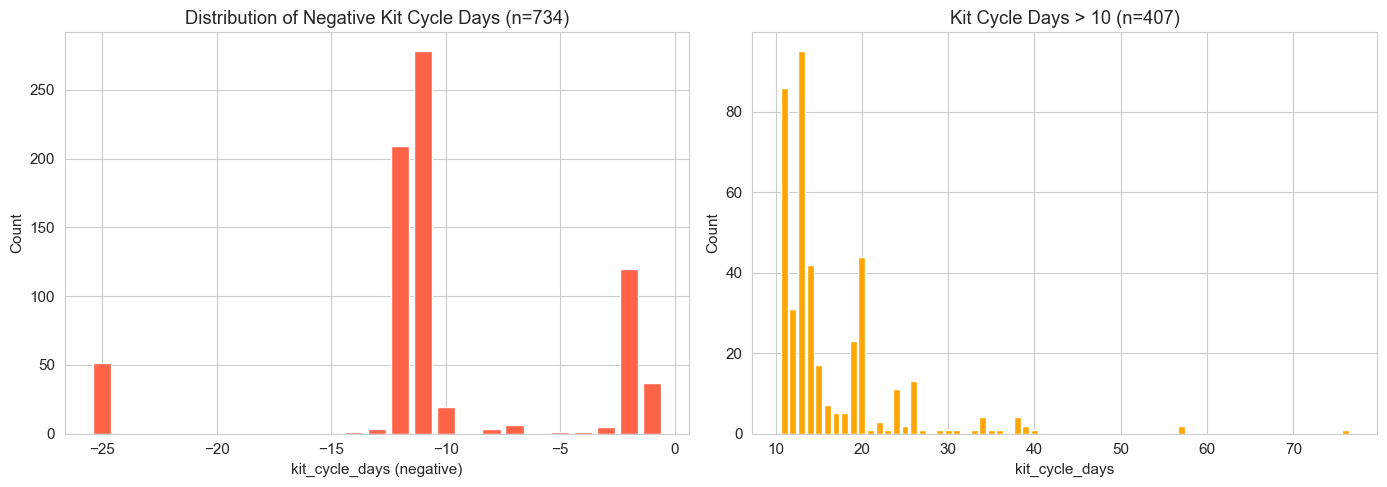

In [11]:
# Visualize negative cycle times
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: distribution of negative values
neg_vals = negative_cycle['kit_cycle_days'].value_counts().sort_index()
axes[0].bar(neg_vals.index, neg_vals.values, color='tomato')
axes[0].set_xlabel('kit_cycle_days (negative)')
axes[0].set_ylabel('Count')
axes[0].set_title(f'Distribution of Negative Kit Cycle Days (n={len(negative_cycle)})')

# Right: extreme outliers on the positive side
extreme = df[df['kit_cycle_days'] > 10]
ext_vals = extreme['kit_cycle_days'].value_counts().sort_index()
axes[1].bar(ext_vals.index, ext_vals.values, color='orange')
axes[1].set_xlabel('kit_cycle_days')
axes[1].set_ylabel('Count')
axes[1].set_title(f'Kit Cycle Days > 10 (n={len(extreme)})')

plt.tight_layout()
plt.show()

** Insight — Data Quality Issues:**

| Issue | Count | Severity | Action |
|-------|-------|----------|--------|
| Negative cycle times | 734 (0.41%) | High | **Remove** — clearly erroneous records |
| est_ship_date = 1900 | 28 | Medium | Treat as missing; create `est_ship_missing` flag |
| est_ship_date < kit_start | ~2,500 | Low | May be intentional (backlog); create flag |
| order_amt = 0 | 2,049 | Low | Create `is_zero_order_amt` flag |
| Capacity hours > 24 | Small | Medium | Cap OT hours at reasonable max (8h) |

## 2.6 Target Variable Analysis

In [12]:
# kit_cycle_days distribution (after removing negatives for clean analysis)
df_clean = df[df['kit_cycle_days'] >= 0].copy()

print(f"Target: kit_cycle_days (after removing {len(negative_cycle)} negative rows)")
print(f"{'='*50}")
print(df_clean['kit_cycle_days'].describe())
print(f"\nMode: {df_clean['kit_cycle_days'].mode()[0]}")
print(f"Skewness: {df_clean['kit_cycle_days'].skew():.2f}")
print(f"Kurtosis: {df_clean['kit_cycle_days'].kurtosis():.2f}")

Target: kit_cycle_days (after removing 734 negative rows)
count    179119.000000
mean          1.385626
std           1.410871
min           0.000000
25%           1.000000
50%           1.000000
75%           2.000000
max          76.000000
Name: kit_cycle_days, dtype: float64

Mode: 1
Skewness: 6.28
Kurtosis: 136.45


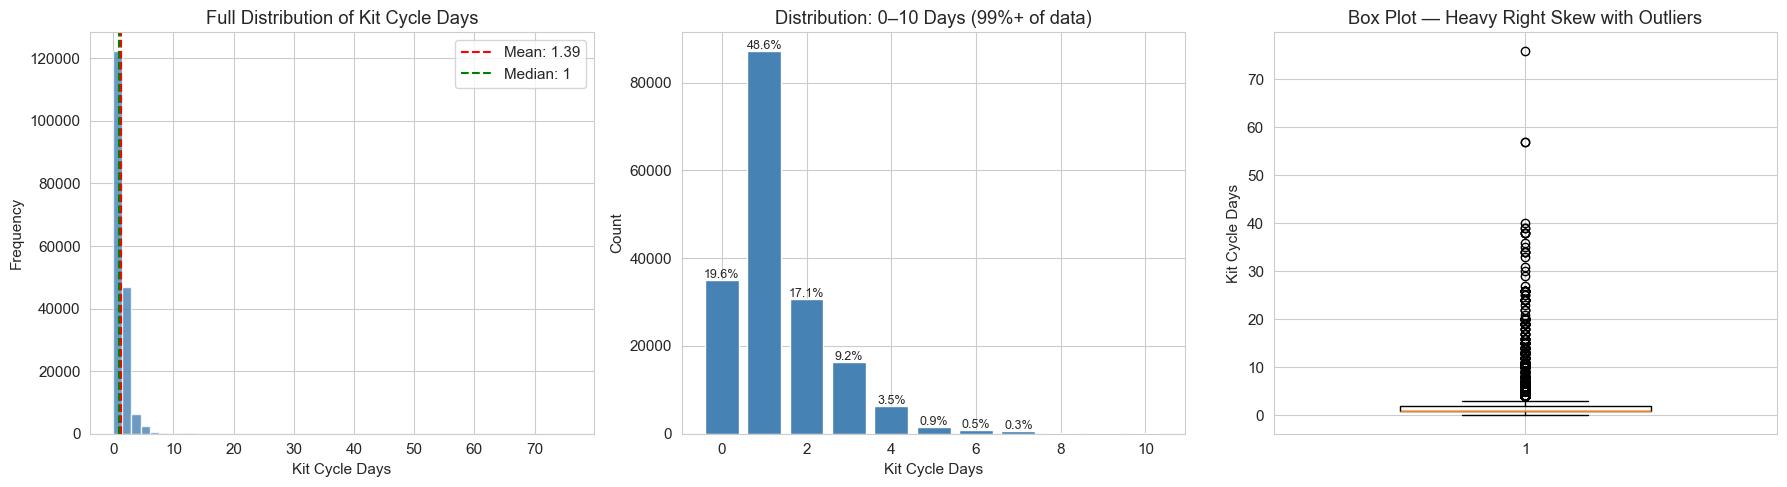


Percentage of orders per kit_cycle_days:
  0 days: 19.6%
  1 days: 48.6%
  2 days: 17.1%
  3 days: 9.2%
  4 days: 3.5%
  5 days: 0.9%
  6 days: 0.5%
  7 days: 0.3%
  8+ days: 0.4%


In [13]:
# Target distribution visualization
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Full distribution
axes[0].hist(df_clean['kit_cycle_days'], bins=50, color='steelblue', edgecolor='white', alpha=0.8)
axes[0].set_xlabel('Kit Cycle Days')
axes[0].set_ylabel('Frequency')
axes[0].set_title('Full Distribution of Kit Cycle Days')
axes[0].axvline(df_clean['kit_cycle_days'].mean(), color='red', linestyle='--', label=f"Mean: {df_clean['kit_cycle_days'].mean():.2f}")
axes[0].axvline(df_clean['kit_cycle_days'].median(), color='green', linestyle='--', label=f"Median: {df_clean['kit_cycle_days'].median():.0f}")
axes[0].legend()

# Zoomed to 0–10 (covers 99%+ of data)
vals = df_clean['kit_cycle_days'].value_counts().sort_index()
axes[1].bar(vals.index[:11], vals.values[:11], color='steelblue', edgecolor='white')
axes[1].set_xlabel('Kit Cycle Days')
axes[1].set_ylabel('Count')
axes[1].set_title('Distribution: 0–10 Days (99%+ of data)')
for i, (x, y) in enumerate(zip(vals.index[:11], vals.values[:11])):
    if y > 500:
        axes[1].text(x, y + 500, f'{y/len(df_clean)*100:.1f}%', ha='center', fontsize=9)

# Box plot
axes[2].boxplot(df_clean['kit_cycle_days'], vert=True, widths=0.5)
axes[2].set_ylabel('Kit Cycle Days')
axes[2].set_title('Box Plot — Heavy Right Skew with Outliers')

plt.tight_layout()
plt.show()

print(f"\nPercentage of orders per kit_cycle_days:")
for d in range(8):
    pct = (df_clean['kit_cycle_days'] == d).sum() / len(df_clean) * 100
    print(f"  {d} days: {pct:.1f}%")
print(f"  8+ days: {(df_clean['kit_cycle_days'] >= 8).sum() / len(df_clean) * 100:.1f}%")

** Insight — Target Variable Characteristics:**
- **Heavily right-skewed** (skew ≈ 6.7) — most orders complete in 0–3 days
- **Dominant class: 1 day** (48.6%) → model will naturally predict ~1 day often
- **0-day completions: 19.6%** → same-day kitting is common
- **Long tail**: a few orders take 10–76 days (outliers)
- This distribution suggests treating it as **regression** (not classification), with potential benefit from **clipping outliers** at ~7 days (99th percentile) during training

## 2.7 Univariate Analysis

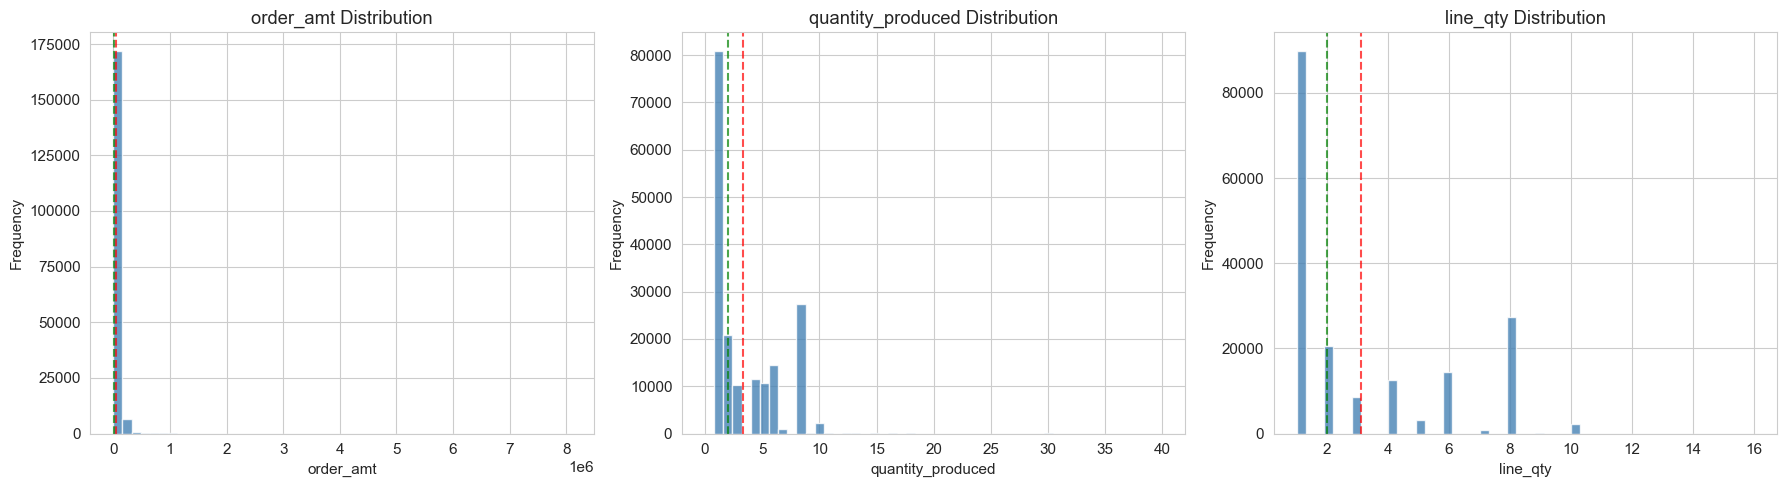


order_amt: mean=40285.25, median=15620.00, skew=22.54, zeros=2049

quantity_produced: mean=3.33, median=2.00, skew=1.29, zeros=4

line_qty: mean=3.11, median=2.00, skew=0.97, zeros=0


In [14]:
# Numerical features distributions
num_cols = ['order_amt', 'quantity_produced', 'line_qty']

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for i, col in enumerate(num_cols):
    axes[i].hist(df[col], bins=50, color='steelblue', edgecolor='white', alpha=0.8)
    axes[i].set_title(f'{col} Distribution')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Frequency')
    # Add stats
    axes[i].axvline(df[col].mean(), color='red', linestyle='--', alpha=0.7)
    axes[i].axvline(df[col].median(), color='green', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

for col in num_cols:
    print(f"\n{col}: mean={df[col].mean():.2f}, median={df[col].median():.2f}, "
          f"skew={df[col].skew():.2f}, zeros={( df[col]==0).sum()}")

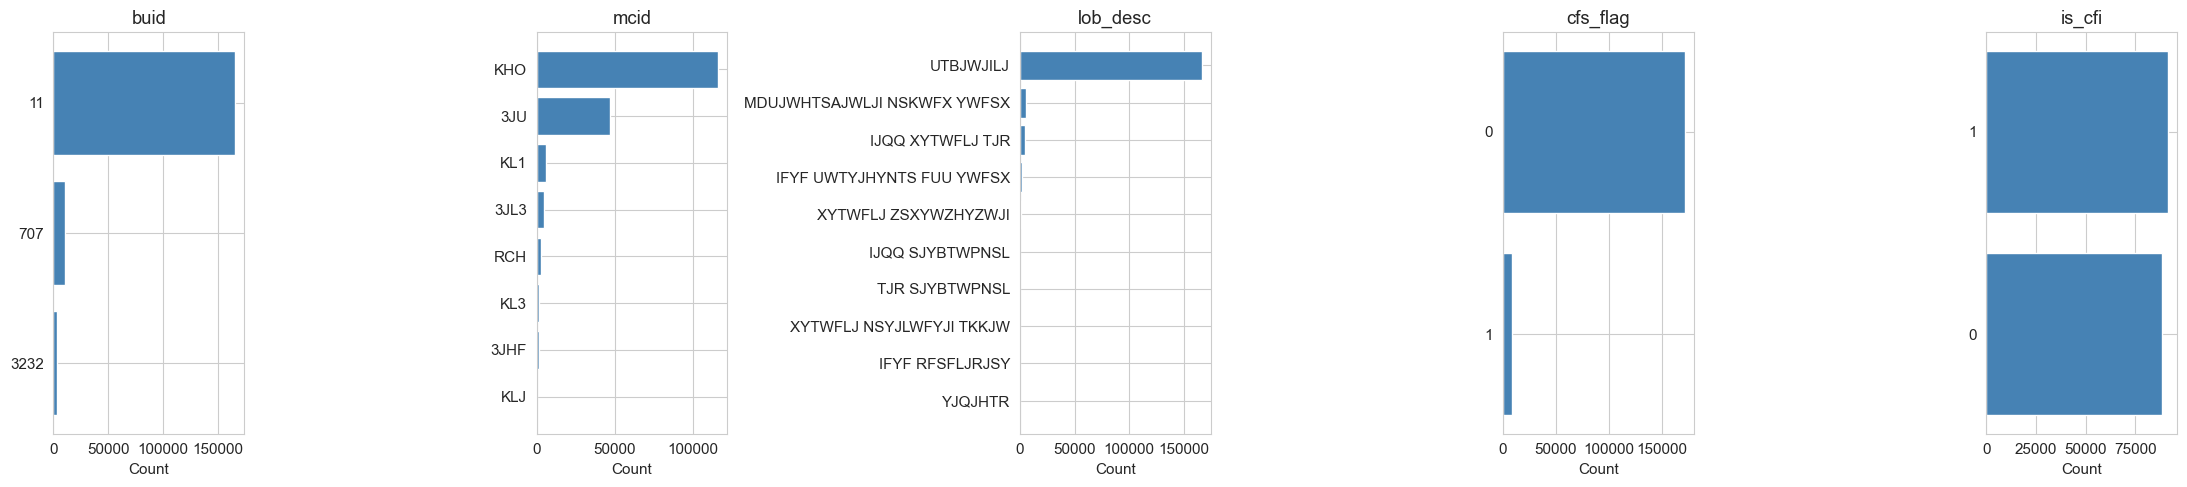

In [15]:
# Categorical features value counts
cat_cols = ['buid', 'mcid', 'lob_desc', 'cfs_flag', 'is_cfi']

fig, axes = plt.subplots(1, 5, figsize=(22, 5))
for i, col in enumerate(cat_cols):
    vc = df[col].value_counts().head(10)
    axes[i].barh(vc.index.astype(str), vc.values, color='steelblue')
    axes[i].set_title(f'{col}')
    axes[i].set_xlabel('Count')
    axes[i].invert_yaxis()

plt.tight_layout()
plt.show()

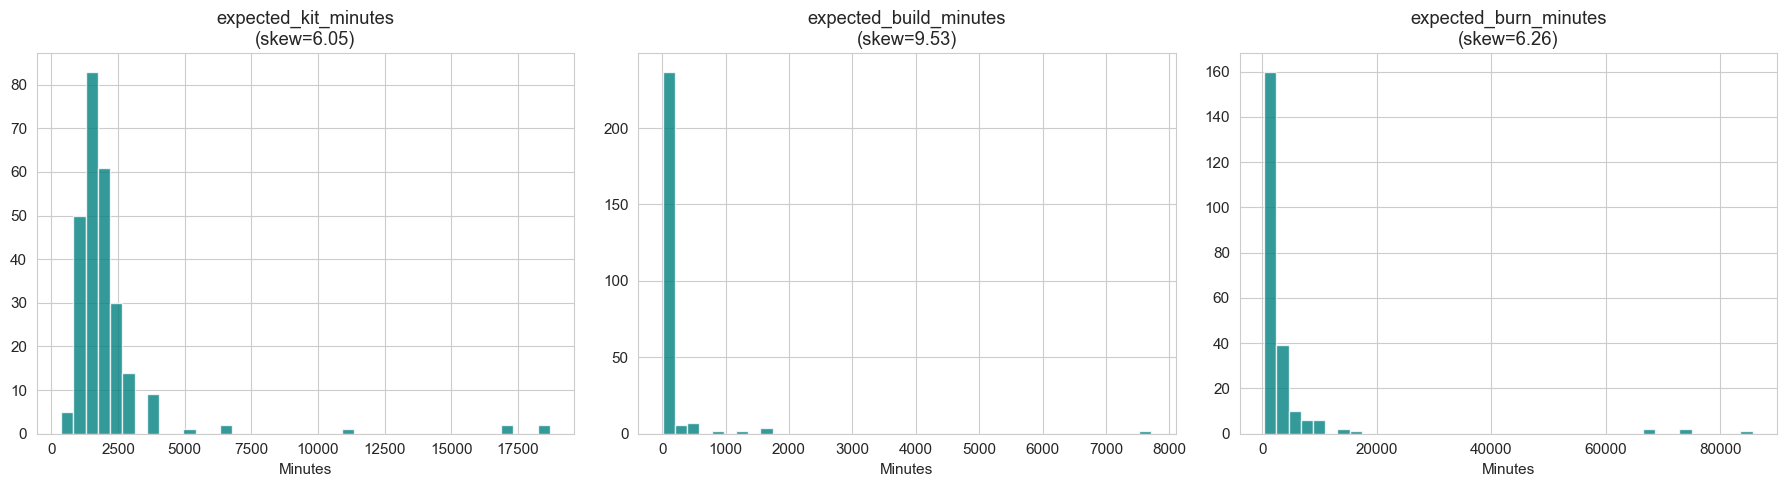

In [16]:
# Expected minutes distributions
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for i, col in enumerate(['expected_kit_minutes', 'expected_build_minutes', 'expected_burn_minutes']):
    data = expected_df[col].dropna()
    axes[i].hist(data, bins=40, color='teal', edgecolor='white', alpha=0.8)
    axes[i].set_title(f'{col}\n(skew={data.skew():.2f})')
    axes[i].set_xlabel('Minutes')

plt.tight_layout()
plt.show()

In [17]:
# Calendar features — holiday/weekend/IDC/EOQ frequency
cal = calendar_df.copy()
print("=== Calendar Feature Frequencies ===")
print(f"is_weekend=1: {cal['is_weekend'].sum()} / {len(cal)} days ({cal['is_weekend'].mean()*100:.1f}%)")
print(f"is_holiday=1: {cal['is_holiday'].sum()} / {len(cal)} days ({cal['is_holiday'].mean()*100:.1f}%)")
print(f"is_idc=1:     {cal['is_idc'].sum()} / {len(cal)} days ({cal['is_idc'].mean()*100:.1f}%)")
print(f"is_eoq=1:     {cal['is_eoq'].sum()} / {len(cal)} days ({cal['is_eoq'].mean()*100:.1f}%)")

# Note: day_of_week where 1 = Saturday
print(f"\nday_of_week mapping (1=Saturday):")
print(cal['day_of_week'].value_counts().sort_index())

=== Calendar Feature Frequencies ===
is_weekend=1: 106 / 370 days (28.6%)
is_holiday=1: 12 / 370 days (3.2%)
is_idc=1:     56 / 370 days (15.1%)
is_eoq=1:     56 / 370 days (15.1%)

day_of_week mapping (1=Saturday):
day_of_week
1    53
2    53
3    53
4    53
5    52
6    53
7    53
Name: count, dtype: int64


**  Insight — Univariate Analysis Summary:**
- **order_amt**: Heavily right-skewed (skew ~20+), needs log transform. 2,049 zeros.
- **quantity_produced**: Most orders have 1–8 units. Median = 2.
- **line_qty**: Similar to quantity_produced. Most = 1.
- **buid**: Dominated by buid=11 (92.3%). Two rare business units (707, 3232).
- **mcid**: KHO (64.6%) and 3JU (26.1%) dominate. 6 other warehouses are rare.
- **lob_desc**: 92.4% is one product line. 9 others are very sparse.
- **cfs_flag**: 95.3% = 0. Very imbalanced.
- **is_cfi**: ~50/50 split — useful feature.
- **Expected minutes**: All three are right-skewed → log transform recommended.
- **Calendar**: ~28% weekends, ~3% holidays, ~15% IDC weeks, ~15% EOQ weeks.

## 2.8 Bivariate Analysis — Features vs Target

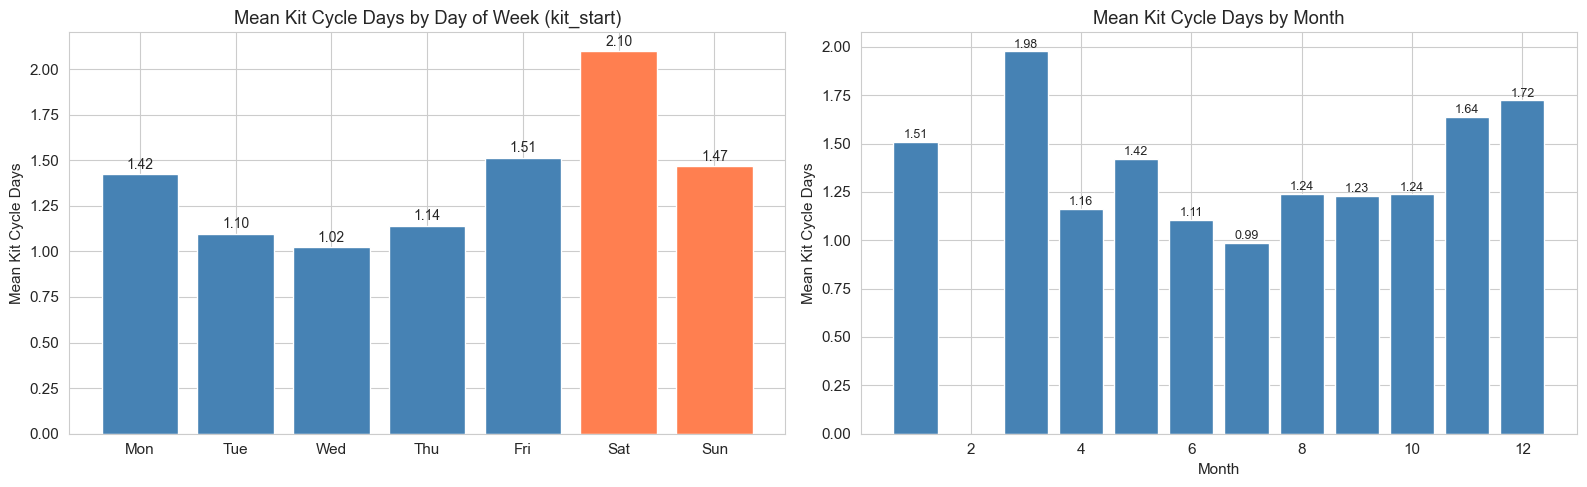

In [18]:
# kit_cycle_days by day of week (STRONGEST signal)
df_clean['kit_start_dow'] = df_clean['kit_start'].dt.dayofweek  # 0=Mon

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

dow_stats = df_clean.groupby('kit_start_dow')['kit_cycle_days'].agg(['mean', 'median', 'count'])
dow_labels = ['Mon','Tue','Wed','Thu','Fri','Sat','Sun']
axes[0].bar(range(7), dow_stats['mean'], color=['steelblue']*5 + ['coral']*2, edgecolor='white')
axes[0].set_xticks(range(7))
axes[0].set_xticklabels(dow_labels)
axes[0].set_ylabel('Mean Kit Cycle Days')
axes[0].set_title('Mean Kit Cycle Days by Day of Week (kit_start)')
for i, v in enumerate(dow_stats['mean']):
    axes[0].text(i, v + 0.03, f'{v:.2f}', ha='center', fontsize=10)

# by month
month_stats = df_clean.groupby(df_clean['kit_start'].dt.month)['kit_cycle_days'].mean()
axes[1].bar(month_stats.index, month_stats.values, color='steelblue', edgecolor='white')
axes[1].set_xlabel('Month')
axes[1].set_ylabel('Mean Kit Cycle Days')
axes[1].set_title('Mean Kit Cycle Days by Month')
for m, v in zip(month_stats.index, month_stats.values):
    axes[1].text(m, v + 0.02, f'{v:.2f}', ha='center', fontsize=9)

plt.tight_layout()
plt.show()

** Insight — Day of Week is the STRONGEST Predictor:**
- **Saturday starts** have the highest mean cycle time (~2.1 days) — production pauses over the weekend
- **Tuesday** starts are fastest (~0.85 days) — full week ahead
- **Friday** starts are slower (~1.49 days) — kit spans into weekend
- **Monthly pattern**: March is slowest (~2.0 days), July is fastest (~0.58 days)

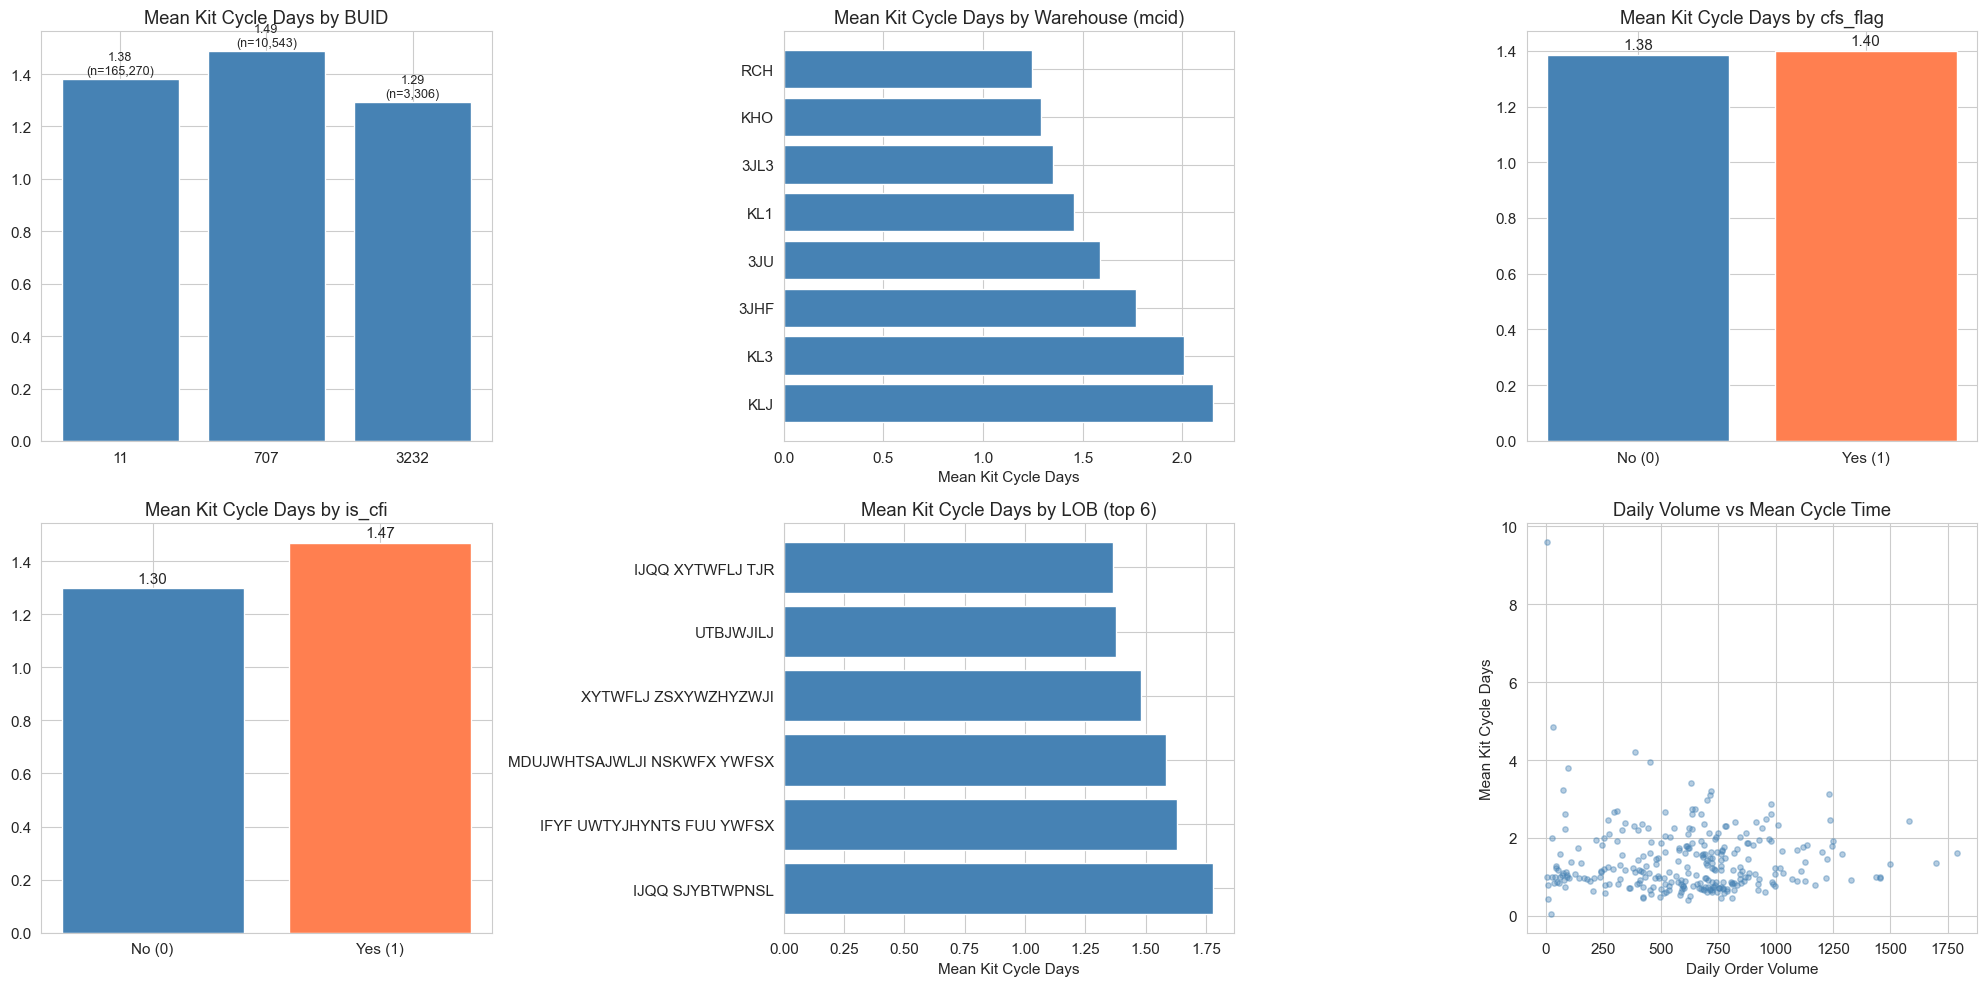

In [19]:
# kit_cycle_days by categorical features
fig, axes = plt.subplots(2, 3, figsize=(20, 10))

# By buid
grp = df_clean.groupby('buid')['kit_cycle_days'].agg(['mean','count']).reset_index()
axes[0,0].bar(grp['buid'].astype(str), grp['mean'], color='steelblue')
axes[0,0].set_title('Mean Kit Cycle Days by BUID')
for i, (b, m, c) in enumerate(zip(grp['buid'], grp['mean'], grp['count'])):
    axes[0,0].text(i, m+0.02, f'{m:.2f}\n(n={c:,})', ha='center', fontsize=9)

# By mcid
grp = df_clean.groupby('mcid')['kit_cycle_days'].agg(['mean','count']).sort_values('mean', ascending=False).reset_index()
axes[0,1].barh(grp['mcid'], grp['mean'], color='steelblue')
axes[0,1].set_title('Mean Kit Cycle Days by Warehouse (mcid)')
axes[0,1].set_xlabel('Mean Kit Cycle Days')

# By cfs_flag
grp = df_clean.groupby('cfs_flag')['kit_cycle_days'].mean()
axes[0,2].bar(['No (0)','Yes (1)'], grp.values, color=['steelblue','coral'])
axes[0,2].set_title('Mean Kit Cycle Days by cfs_flag')
for i, v in enumerate(grp.values):
    axes[0,2].text(i, v+0.02, f'{v:.2f}', ha='center')

# By is_cfi
grp = df_clean.groupby('is_cfi')['kit_cycle_days'].mean()
axes[1,0].bar(['No (0)','Yes (1)'], grp.values, color=['steelblue','coral'])
axes[1,0].set_title('Mean Kit Cycle Days by is_cfi')
for i, v in enumerate(grp.values):
    axes[1,0].text(i, v+0.02, f'{v:.2f}', ha='center')

# By lob_desc (top 6)
grp = df_clean.groupby('lob_desc')['kit_cycle_days'].agg(['mean','count']).sort_values('count', ascending=False).head(6).sort_values('mean', ascending=False).reset_index()
axes[1,1].barh(grp['lob_desc'], grp['mean'], color='steelblue')
axes[1,1].set_title('Mean Kit Cycle Days by LOB (top 6)')
axes[1,1].set_xlabel('Mean Kit Cycle Days')

# Kit cycle vs daily volume (scatter)
daily = df_clean.groupby(df_clean['kit_start'].dt.date).agg(
    mean_cycle=('kit_cycle_days','mean'),
    volume=('kit_cycle_days','count')
)
axes[1,2].scatter(daily['volume'], daily['mean_cycle'], alpha=0.4, s=15, color='steelblue')
axes[1,2].set_xlabel('Daily Order Volume')
axes[1,2].set_ylabel('Mean Kit Cycle Days')
axes[1,2].set_title('Daily Volume vs Mean Cycle Time')

plt.tight_layout()
plt.show()

Correlation with kit_cycle_days:
kit_start_dow           0.209377
log_order_amt           0.073529
is_cfi                  0.060562
order_amt               0.053889
download_to_kit_days    0.041193
cfs_flag                0.002210
buid                   -0.001957
quantity_produced      -0.042432
line_qty               -0.047007


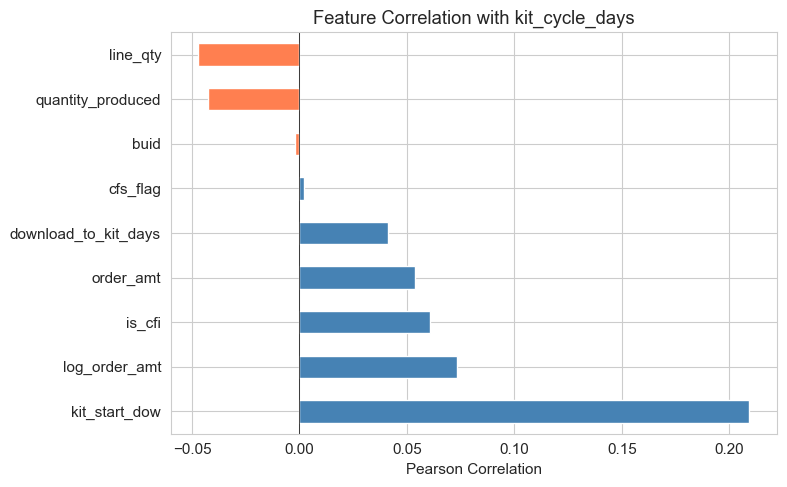

In [20]:
# Correlation analysis — numeric features vs target
numeric_features = df_clean[['kit_cycle_days', 'order_amt', 'quantity_produced', 
                             'line_qty', 'cfs_flag', 'is_cfi', 'buid']].copy()
numeric_features['kit_start_dow'] = df_clean['kit_start'].dt.dayofweek
numeric_features['download_to_kit_days'] = (df_clean['kit_start'] - df_clean['download_date']).dt.days
numeric_features['log_order_amt'] = np.log1p(df_clean['order_amt'])

corr = numeric_features.corr()['kit_cycle_days'].drop('kit_cycle_days').sort_values(ascending=False)
print("Correlation with kit_cycle_days:")
print(corr.to_string())

fig, ax = plt.subplots(figsize=(8, 5))
corr.plot(kind='barh', color=['coral' if v < 0 else 'steelblue' for v in corr], ax=ax)
ax.set_title('Feature Correlation with kit_cycle_days')
ax.set_xlabel('Pearson Correlation')
ax.axvline(0, color='black', linewidth=0.5)
plt.tight_layout()
plt.show()

** Insight — Bivariate Analysis Summary:**
- **mcid (warehouse)**: Clear variation — KL3 warehouse averages ~2.0 days vs RCH at ~1.2 days
- **is_cfi**: Orders with software customization take 0.22 days longer on average (1.45 vs 1.23)
- **cfs_flag**: Almost no difference (0→1.34 vs 1→1.33) — weak predictor
- **buid**: Slight variation (707 is slightly slower at 1.44 vs 11 at 1.33)
- **Daily volume vs cycle time**: Slight positive trend — busier days tend to have longer cycles
- **download_to_kit_days**: Weak positive correlation — orders that wait longer before kitting tend to have slightly longer cycle times

## 2.9 Cross-Dataset Coverage Check

In [21]:
# Family desc coverage across datasets
train_families    = set(train_df['family_desc'].unique())
inf_families      = set(inference_df['family_desc'].unique())
exp_families      = set(expected_df['family_desc'].dropna().unique())

print("=== Family Desc Coverage ===")
print(f"Train families:                       {len(train_families)}")
print(f"Inference families:                    {len(inf_families)}")
print(f"Expected minutes families:             {len(exp_families)}")
print(f"Train ∩ Expected minutes:              {len(train_families & exp_families)}")
print(f"Train families NOT in expected mins:   {len(train_families - exp_families)}")
print(f"Inference ∩ Expected minutes:           {len(inf_families & exp_families)}")
print(f"Inference families NOT in train:        {len(inf_families - train_families)}")
if inf_families - train_families:
    print(f"  Unseen families: {inf_families - train_families}")

=== Family Desc Coverage ===
Train families:                       360
Inference families:                    210
Expected minutes families:             259
Train ∩ Expected minutes:              166
Train families NOT in expected mins:   194
Inference ∩ Expected minutes:           133
Inference families NOT in train:        2
  Unseen families: {'LJSYWD IXX', 'UFQT IZWT UJ'}


** Insight — Coverage Gaps:**
- Only 166 of 360 train families have expected_minutes data (46%) → imputation needed for ~54% of families
- 2 inference families don't exist in train at all → model needs to handle unseen categories gracefully
- 77 inference families don't have expected_minutes → need hierarchical imputation

## 2.10 Feature Importance Intuition

** Based on EDA, the expected feature importance ranking is:**

| Rank | Feature | Rationale |
|------|---------|-----------|
| 1 | `kit_start_day_of_week` | Strongest signal — Friday/Saturday starts take much longer |
| 2 | `daily_volume` (from capacity) | Busier days → longer cycles; factory load matters |
| 3 | `expected_kit_minutes` | Direct proxy for product kit complexity |
| 4 | `family_desc` (encoded) | Product-level variation in cycle time |
| 5 | `mcid` (warehouse) | Different warehouses have different efficiency |
| 6 | `is_eoq` / `fiscal_qtr_weeknum` | End-of-quarter rush affects cycle time |
| 7 | `download_to_kit_start_days` | Lead time as order complexity proxy |
| 8 | `ot_flag` / `total_hours` | Available capacity |
| 9 | `quantity_produced` | Larger orders take longer |
| 10 | `is_cfi` | Software customization adds time |

**Feature engineering ideas :**
1. **Time-based**: day_of_week, month, is_friday, is_weekend_start, days_to_next_weekend
2. **Volume**: daily order volume, rolling 3/7-day volume
3. **Capacity**: ot_ratio, capacity_minutes, kit_to_capacity_ratio
4. **Product complexity**: expected_kit_in_days = kit_minutes * qty / capacity_minutes
5. **Lead time**: download_to_kit_days, days_until_ship, ship_urgency
6. **Encoding**: Target encoding for family_desc, family_parent_desc, mcid
7. **Rolling/lag**: family-level rolling mean cycle time (7-day, 30-day)

## 2.11 Data Leakage Check

** Potential Leakage Sources:**

| Risk | Column/Feature | Why | Mitigation |
|------|---------------|-----|------------|
|  High | `kit_end` used in target encoding | Computing means from same time period | Use **time-aware** expanding-window encoding |
|  High | Rolling features from future data | If not sorted by time before computing | Always `shift(1)` and use only past data |
|  Medium | `est_ship_date` | May be set after kit process starts | Acceptable — it's set at order time |
|  Low | Calendar/capacity features | Based on kit_start date | No leakage — available at prediction time |
|  Low | Expected minutes | Static product attributes | No leakage — known before kitting |

**Validation strategy:** Use **time-based split** (train on data before Dec 2025, validate on Dec 2025 – Jan 2026) to simulate real prediction scenarios.

## 2.12 EDA Summary

---
##  EDA Summary & Next Steps

**Key Findings:**
1. Target is heavily right-skewed (mode=1 day, 48.6% of data)
2. 734 impossible rows (negative cycle time) — must remove
3. Day-of-week is the strongest predictor (Friday/weekend starts = longer)
4. Capacity data rows = order volume (don't drop "duplicates"!)
5. ~54% of products lack expected_minutes data — needs hierarchical imputation
6. Factory has single site (KHO), one product type → drop zero-variance columns

**Next:** Data Cleaning Notebook → fix quality issues identified above

---
# 3. Data Cleaning & Preprocessing

Fix all data quality issues identified in EDA. Uses the datasets already loaded in Section 1.

## 3.1 Fix Data Types

In [22]:
# Convert date columns — all datasets
for col in ['download_date', 'kit_start', 'kit_end', 'est_ship_date']:
    if col in train_df.columns:
        train_df[col] = pd.to_datetime(train_df[col], errors='coerce')
    if col in inference_df.columns:
        inference_df[col] = pd.to_datetime(inference_df[col], errors='coerce')

calendar_df['date'] = pd.to_datetime(calendar_df['date'], errors='coerce')
capacity_df['date'] = pd.to_datetime(capacity_df['date'], errors='coerce')

# buid is categorical (3 values: 11, 707, 3232), not numeric
train_df['buid'] = train_df['buid'].astype(str)
inference_df['buid'] = inference_df['buid'].astype(str)

print(" Date columns converted to datetime")
print(" buid converted to categorical string")

 Date columns converted to datetime
 buid converted to categorical string


## 3.2 Drop Zero-Variance Columns

In [23]:
# site (1 value: KHO) and alt_type_desc (1 value) carry zero information
for df in [train_df, inference_df]:
    df.drop(columns=['site', 'alt_type_desc'], errors='ignore', inplace=True)

print(" Dropped 'site' and 'alt_type_desc' (zero variance)")

 Dropped 'site' and 'alt_type_desc' (zero variance)


## 3.3 Handle Missing Values

In [24]:
# 3.3a Train: Impute 5 null download_dates
null_download = train_df['download_date'].isnull()
train_df.loc[null_download, 'download_date'] = train_df.loc[null_download, 'kit_start'] - pd.Timedelta(days=1)
print(f" download_date: {null_download.sum()} nulls imputed with kit_start - 1 day")

# 3.3b Capacity: Drop 12 rows with null dates
cap_nulls = capacity_df['date'].isnull().sum()
capacity_df = capacity_df.dropna(subset=['date'])
print(f" capacity: {cap_nulls} null-date rows dropped")

# 3.3c Expected minutes: Drop 1 null family_desc, impute 31 null burn_minutes
expected_df = expected_df.dropna(subset=['family_desc'])
### Commenting it out fro now will treat these null values with in a heirarchial level of imputation so will deal in teh section 3.6 will leave as is here 
#burn_median = expected_df['expected_burn_minutes'].median()
#expected_df['expected_burn_minutes'] = expected_df['expected_burn_minutes'].fillna(burn_median)
#print(f" expected_minutes: null family dropped, {31} null burn_minutes imputed with median ({burn_median:.0f})")

 download_date: 5 nulls imputed with kit_start - 1 day
 capacity: 12 null-date rows dropped


## 3.4 Remove Impossible / Incorrect Values

In [25]:
# 3.4a Remove negative kit_cycle_days (kit_end < kit_start)
impossible = train_df['kit_end'] < train_df['kit_start']
print(f"Rows with kit_end < kit_start: {impossible.sum()}")
train_df = train_df[~impossible].copy()
print(f" Removed {impossible.sum()} impossible records. Train: {len(train_df)} rows")

# 3.4b Fix est_ship_date = 1900-01-01
for df, name in [(train_df, 'train'), (inference_df, 'inference')]:
    bad_ship = df['est_ship_date'].dt.year == 1900
    df['est_ship_date_missing'] = bad_ship.astype(int)
    df.loc[bad_ship, 'est_ship_date'] = pd.NaT
    print(f" {name}: {bad_ship.sum()} bad est_ship_date → flagged and set to NaT")

# 3.4c Cap capacity OT hours at 8
capacity_df.loc[capacity_df['ot_hours'] > 8, 'ot_hours'] = 8
print(" Capacity: OT hours capped at 8")

Rows with kit_end < kit_start: 734
 Removed 734 impossible records. Train: 179119 rows
 train: 28 bad est_ship_date → flagged and set to NaT
 inference: 1 bad est_ship_date → flagged and set to NaT
 Capacity: OT hours capped at 8


## 3.5 Aggregate Supplementary Datasets

In [26]:
# 3.5a Capacity: aggregate to daily level (rows = individual orders, NOT duplicates)
capacity_daily = capacity_df.groupby('date').agg(
    daily_volume  = ('ot_flag', 'count'),
    ot_flag       = ('ot_flag', 'max'),
    regular_hours = ('regular_hours', 'first'),
    ot_hours      = ('ot_hours', 'first'),
).reset_index()
capacity_daily['total_hours'] = capacity_daily['regular_hours'] + capacity_daily['ot_hours']
capacity_daily['capacity_minutes'] = capacity_daily['total_hours'] * 60
print(f" Capacity aggregated: {len(capacity_df)} rows → {len(capacity_daily)} daily rows")

# 3.5b Calendar: drop 'site' column (masked data — FCJ vs KHO)
calendar_df.drop(columns=['site'], errors='ignore', inplace=True)
print(f" Calendar cleaned: {len(calendar_df)} rows")

# 3.5c Merge calendar + capacity into date lookup
date_features = calendar_df.merge(capacity_daily, on='date', how='left')
for col in ['daily_volume','ot_flag','regular_hours','ot_hours','total_hours','capacity_minutes']:
    date_features[col] = date_features[col].fillna(0)
print(f" Date features lookup: {date_features.shape}")

 Capacity aggregated: 191922 rows → 317 daily rows
 Calendar cleaned: 370 rows
 Date features lookup: (370, 22)


## 3.6 Merge All Datasets

In [27]:
# 3.6a Merge expected minutes onto train and inference
expected_cols = ['family_desc', 'expected_build_minutes', 'expected_burn_minutes', 'expected_kit_minutes']
train_merged = train_df.merge(expected_df[expected_cols], on='family_desc', how='left')
inference_merged = inference_df.merge(expected_df[expected_cols], on='family_desc', how='left')

# Process hours: on weekends/holidays, regular_hours is actually overtime
def process_hours(df):
    if 'regular_hours' not in df.columns:
        return df
    reg = pd.to_numeric(df["regular_hours"], errors="coerce").fillna(0)
    ot = pd.to_numeric(df["ot_hours"], errors="coerce").fillna(0)
    weekend_or_holiday = (df["is_weekend"] == 1) | (df["is_holiday"] == 1)
    df["ot_hours"] = np.where(weekend_or_holiday, ot + reg, ot)
    df["regular_hours"] = np.where(weekend_or_holiday, 0, reg)
    return df

print(f"Train with expected_minutes: {train_merged['expected_kit_minutes'].notna().sum()}/{len(train_merged)} "
      f"({train_merged['expected_kit_minutes'].notna().mean()*100:.1f}%)")
verbose=True
levels = ["family_parent_desc", "lob_desc"]
# 3.6b Impute missing expected_minutes using hierarchy
for df in [train_merged, inference_merged]:
    for c in ['expected_build_minutes', 'expected_burn_minutes', 'expected_kit_minutes']:
        if verbose:
            print(f"\n===== {c} =====")
        
        initial = df[c].isna().sum()
        if verbose:
            print(f"Initial missing: {initial}")
        
        prev_missing = initial

        # Level-wise imputation
        for i, key in enumerate(levels, start=1):
            df[c] = df[c].fillna(
                df.groupby(key)[c].transform("median")
            )
            
            after = df[c].isna().sum()
            rescued = prev_missing - after
            
            if verbose:
                print(f"Level {i} ({key}) rescued: {rescued} | Remaining: {after}")
            
            prev_missing = after

        # Global median
        df[c] = df[c].fillna(df[c].median())
        
        final_missing = df[c].isna().sum()
        rescued_global = prev_missing - final_missing
        
        if verbose:
            print(f"Level {len(levels)+1} (Global) rescued: {rescued_global} | Final missing: {final_missing}")

print(" Hierarchical imputation complete for expected_minutes")

# 3.6c Merge date features (calendar + capacity) on kit_start
train_merged = train_merged.merge(date_features, left_on=train_merged['kit_start'].dt.normalize(),
    right_on='date', how='left').drop(columns=['key_0', 'date'], errors='ignore')
inference_merged = inference_merged.merge(date_features, left_on=inference_merged['kit_start'].dt.normalize(),
    right_on='date', how='left').drop(columns=['key_0', 'date'], errors='ignore')

train_merged = process_hours(train_merged)
inference_merged = process_hours(inference_merged)
print(f" Date features merged. Train: {train_merged.shape}, Inference: {inference_merged.shape}")

Train with expected_minutes: 135197/179119 (75.5%)

===== expected_build_minutes =====
Initial missing: 43922
Level 1 (family_parent_desc) rescued: 0 | Remaining: 43922
Level 2 (lob_desc) rescued: 35167 | Remaining: 8755
Level 3 (Global) rescued: 8755 | Final missing: 0

===== expected_burn_minutes =====
Initial missing: 52355
Level 1 (family_parent_desc) rescued: 0 | Remaining: 52355
Level 2 (lob_desc) rescued: 43600 | Remaining: 8755
Level 3 (Global) rescued: 8755 | Final missing: 0

===== expected_kit_minutes =====
Initial missing: 43922
Level 1 (family_parent_desc) rescued: 0 | Remaining: 43922
Level 2 (lob_desc) rescued: 35167 | Remaining: 8755
Level 3 (Global) rescued: 8755 | Final missing: 0

===== expected_build_minutes =====
Initial missing: 2390
Level 1 (family_parent_desc) rescued: 0 | Remaining: 2390
Level 2 (lob_desc) rescued: 1732 | Remaining: 658
Level 3 (Global) rescued: 658 | Final missing: 0

===== expected_burn_minutes =====
Initial missing: 2839
Level 1 (family_pare

## 3.7 Create Target Variable

In [28]:
# Target = calendar days from kit_start to kit_end (same day = 0)
train_merged['kit_cycle_days'] = (train_merged['kit_end'] - train_merged['kit_start']).dt.days

print("Target variable created: kit_cycle_days")
print(train_merged['kit_cycle_days'].describe())
print(f"\nDistribution:")
for d in range(8):
    count = (train_merged['kit_cycle_days'] == d).sum()
    print(f"  {d} days: {count:>6,} ({count/len(train_merged)*100:.1f}%)")

Target variable created: kit_cycle_days
count    179119.000000
mean          1.385626
std           1.410871
min           0.000000
25%           1.000000
50%           1.000000
75%           2.000000
max          76.000000
Name: kit_cycle_days, dtype: float64

Distribution:
  0 days: 35,082 (19.6%)
  1 days: 87,105 (48.6%)
  2 days: 30,639 (17.1%)
  3 days: 16,407 (9.2%)
  4 days:  6,268 (3.5%)
  5 days:  1,567 (0.9%)
  6 days:    872 (0.5%)
  7 days:    515 (0.3%)


## 3.8 Fill Remaining Nulls & Validate

In [29]:
# Fill remaining nulls
fill_zero = ['daily_volume','ot_flag','regular_hours','ot_hours','total_hours','capacity_minutes',
             'is_weekend','is_holiday','is_idc','is_eoq']
fill_mode = ['fiscal_year','fiscal_qtr','fiscal_month','fiscal_qtr_weeknum','fiscal_weeknum',
             'calendar_day','day_of_week','calendar_weeknum','calendar_month','calendar_year']

for df in [train_merged, inference_merged]:
    for col in fill_zero:
        if col in df.columns: df[col] = df[col].fillna(0)
    for col in fill_mode:
        if col in df.columns: df[col] = df[col].fillna(df[col].mode()[0] if len(df[col].mode()) > 0 else 0)
    if 'est_ship_date' in df.columns:
        df['est_ship_date'] = df['est_ship_date'].fillna(df['kit_start'] + pd.Timedelta(days=30))

print(f"Train nulls: {train_merged.isnull().sum().sum()}")
print(f"Inference nulls: {inference_merged.isnull().sum().sum()}")
print(f"\n Train: {train_merged.shape}, Inference: {inference_merged.shape}")

Train nulls: 5
Inference nulls: 0

 Train: (179119, 43), Inference: (12069, 41)


## 3.9 Export Cleaned Data

In [30]:
train_merged.to_parquet(f"{INTERMEDIATE_DIR}/cleaned_train.parquet", index=False)
inference_merged.to_parquet(f"{INTERMEDIATE_DIR}/cleaned_inference.parquet", index=False)
print(f" Saved cleaned_train.parquet ({train_merged.shape})")
print(f" Saved cleaned_inference.parquet ({inference_merged.shape})")

 Saved cleaned_train.parquet ((179119, 43))
 Saved cleaned_inference.parquet ((12069, 41))


---
# 4. Feature Engineering

Loads cleaned parquets (fresh checkpoint) and creates all predictive features.

## 4.1 Load Cleaned Data

In [31]:
# Load from checkpoint (clean separation between cleaning and feature engineering)
train_df     = pd.read_parquet(f"{INTERMEDIATE_DIR}/cleaned_train.parquet")
inference_df = pd.read_parquet(f"{INTERMEDIATE_DIR}/cleaned_inference.parquet")

for col in ['download_date', 'kit_start', 'kit_end', 'est_ship_date']:
    if col in train_df.columns: train_df[col] = pd.to_datetime(train_df[col])
    if col in inference_df.columns: inference_df[col] = pd.to_datetime(inference_df[col])

print(f"Train: {train_df.shape}, Inference: {inference_df.shape}")
print(f"Target: {train_df['kit_cycle_days'].describe()}")

Train: (179119, 43), Inference: (12069, 41)
Target: count    179119.000000
mean          1.385626
std           1.410871
min           0.000000
25%           1.000000
50%           1.000000
75%           2.000000
max          76.000000
Name: kit_cycle_days, dtype: float64


In [32]:
train_merged.columns

Index(['sales_order_id', 'buid', 'orig_wo_id', 'tie_num', 'mcid', 'order_amt',
       'quantity_produced', 'line_qty', 'cfs_flag', 'is_cfi', 'lob_desc',
       'family_parent_desc', 'family_desc', 'download_date', 'kit_start',
       'kit_end', 'est_ship_date', 'est_ship_date_missing',
       'expected_build_minutes', 'expected_burn_minutes',
       'expected_kit_minutes', 'fiscal_year', 'fiscal_qtr', 'fiscal_month',
       'fiscal_qtr_weeknum', 'fiscal_weeknum', 'fisc_week_val', 'calendar_day',
       'day_of_week', 'calendar_weeknum', 'calendar_month', 'calendar_year',
       'is_weekend', 'is_holiday', 'is_idc', 'is_eoq', 'daily_volume',
       'ot_flag', 'regular_hours', 'ot_hours', 'total_hours',
       'capacity_minutes', 'kit_cycle_days'],
      dtype='object')

## 4.2 Temporal Features

In [33]:
def create_temporal_features(df):
    """Create time-based features from kit_start date."""
    df = df.copy()
    
    # ── Day-of-week features ──
    df['kit_start_dow'] = df['day_of_week']         # 0=friday, 1=saturday 2= sunday ....... ### as per the calender_schema
    df['is_friday_start'] = (df['kit_start_dow'] == 7).astype(int)   # Friday → spans weekend
    df['is_weekend_start'] = (df['kit_start_dow'] >= 1).astype(int)  # Sat/Sun starts
    df['is_monday_start'] = (df['kit_start_dow'] == 3).astype(int)
    
    # Days until next weekend (Saturday)
    # If today is Monday(3), next Saturday is in 5 days; Friday(7)→1 day; Sat(1)→0
    df['days_to_weekend'] = (5 - df['kit_start_dow']) % 7
    
    # ── Month/Quarter features ──
    df['kit_start_month'] = df['calendar_month']
    df['kit_start_day']   = df['calendar_day']
    df['kit_start_week']  = df['calendar_weeknum'].astype(int)
    
    return df

train_df = create_temporal_features(train_df)
inference_df = create_temporal_features(inference_df)

# Verify the day-of-week signal
print("Mean kit_cycle_days by day of week:")
dow_names = ['Mon','Tue','Wed','Thu','Fri','Sat','Sun']
dow_stats = train_df.groupby('kit_start_dow')['kit_cycle_days'].agg(['mean','count'])
dow_stats.index = dow_names
print(dow_stats)
print("\n Temporal features created")

Mean kit_cycle_days by day of week:
         mean  count
Mon  2.096301  35441
Tue  1.466564   1301
Wed  1.422724  11556
Thu  1.095653  30548
Fri  1.022039  32987
Sat  1.141481  36224
Sun  1.513586  31062

 Temporal features created


## 4.3 Lead Time & Urgency Features

In [34]:
def create_lead_time_features(df):
    """Create features measuring lead times and urgency."""
    df = df.copy()
    
    # ── Download to kit_start lead time ──
    df['download_to_kit_days'] = (df['kit_start'] - df['download_date']).dt.days
    # Clip negative values (rare edge cases) to 0
    df['download_to_kit_days'] = df['download_to_kit_days'].clip(lower=0)
    
    # ── Ship date urgency ──
    df['days_until_ship'] = (df['est_ship_date'] - df['kit_start']).dt.days
    # For missing/bad ship dates, set to a large number (no urgency)
    df['days_until_ship'] = df['days_until_ship'].fillna(90)
    df['days_until_ship'] = df['days_until_ship'].clip(lower=-30, upper=365)  # reasonable bounds
    
    # Urgency indicator: ship date within 7 days
    df['is_urgent_ship'] = (df['days_until_ship'] <= 7).astype(int)
    
    # Ship date missing flag (already created in cleaning, ensure it exists)
    if 'est_ship_date_missing' not in df.columns:
        df['est_ship_date_missing'] = 0
    
    return df

train_df = create_lead_time_features(train_df)
inference_df = create_lead_time_features(inference_df)

print("Lead time feature stats:")
print(train_df[['download_to_kit_days', 'days_until_ship']].describe())
print("\n Lead time & urgency features created")

Lead time feature stats:
       download_to_kit_days  days_until_ship
count         179119.000000    179119.000000
mean               3.353860        27.958368
std                5.578279        34.139212
min                0.000000       -30.000000
25%                1.000000         7.000000
50%                1.000000        12.000000
75%                3.000000        43.000000
max               86.000000       365.000000

 Lead time & urgency features created


## 4.4 Order Complexity Features

In [35]:
def create_order_features(df):
    """Create features measuring order size and complexity."""
    df = df.copy()
    
    # ── Revenue features ──
    df['log_order_amt'] = np.log1p(df['order_amt'])
    df['is_zero_order_amt'] = (df['order_amt'] == 0).astype(int)
    
    # Revenue per unit (complexity proxy)
    df['amt_per_unit'] = df['order_amt'] / df['quantity_produced'].clip(lower=1)
    df['log_amt_per_unit'] = np.log1p(df['amt_per_unit'])
    
    # ── Quantity features ──
    df['is_large_order'] = (df['quantity_produced'] > df['quantity_produced'].quantile(0.75)).astype(int)
    df['units_per_line'] = df['quantity_produced'] / df['line_qty'].clip(lower=1)
    
    # ── Flag features (already binary) ──
    # cfs_flag and is_cfi are already 0/1
    
    # ── Multi-tie indicator ──
    df['is_multi_tie'] = (df['tie_num'] > 1).astype(int)
    
    return df

train_df = create_order_features(train_df)
inference_df = create_order_features(inference_df)

print("Order feature stats:")
print(train_df[['log_order_amt', 'amt_per_unit', 'units_per_line', 'is_large_order']].describe())
print("\n Order complexity features created")

Order feature stats:
       log_order_amt  amt_per_unit  units_per_line  is_large_order
count  179119.000000  1.791190e+05   179119.000000   179119.000000
mean        9.567703  1.560127e+04        1.178311        0.174700
std         1.714671  3.789184e+04        0.816585        0.379711
min         0.000000  0.000000e+00        0.000000        0.000000
25%         8.538933  3.276643e+03        1.000000        0.000000
50%         9.659670  6.040495e+03        1.000000        0.000000
75%        10.646881  1.173089e+04        1.000000        0.000000
max        15.904805  3.085807e+06       15.000000        1.000000

 Order complexity features created


## 4.5 Capacity-Derived Features

In [36]:
def create_capacity_features(df):
    """Create features derived from factory capacity data."""
    df = df.copy()
    
    # ── Consolidate weekend/holiday hours ──
    # On weekends/holidays, regular_hours is actually overtime work
    weekend_or_holiday = (df['is_weekend'] == 1) | (df['is_holiday'] == 1)
    
    df['effective_ot_hours'] = np.where(
        weekend_or_holiday,
        df['ot_hours'] + df['regular_hours'],  # All hours are OT on non-working days
        df['ot_hours']
    )
    df['effective_regular_hours'] = np.where(
        weekend_or_holiday, 0, df['regular_hours']
    )
    
    # ── Capacity utilization ──
    # Guard against division by zero
    safe_total = df['total_hours'].clip(lower=0.1)
    df['ot_ratio'] = df['effective_ot_hours'] / safe_total
    
    # Orders per hour (factory load intensity)
    safe_capacity = df['capacity_minutes'].clip(lower=1)
    df['orders_per_hour'] = df['daily_volume'] / (safe_total)
    
    return df

train_df = create_capacity_features(train_df)
inference_df = create_capacity_features(inference_df)

print("Capacity feature stats:")
print(train_df[['daily_volume', 'ot_ratio', 'orders_per_hour', 'effective_ot_hours']].describe())
print("\n Capacity features created")

Capacity feature stats:
        daily_volume       ot_ratio  orders_per_hour  effective_ot_hours
count  179119.000000  179119.000000    179119.000000       179119.000000
mean      804.819595       0.405869        39.734397            7.941377
std       315.652683       0.325190        16.430143            5.575261
min         0.000000       0.000000         0.000000            0.000000
25%       617.000000       0.255814        30.604651            5.500000
50%       761.000000       0.255814        37.444444            5.500000
75%       980.000000       0.255814        46.833333            5.500000
max      1788.000000       1.000000       310.000000           24.000000

 Capacity features created


## 4.6 Product Complexity Features

In [37]:
def create_product_features(df):
    """Create features from expected manufacturing minutes."""
    df = df.copy()
    
    # ── Log transforms (right-skewed distributions) ──
    df['log_expected_kit']   = np.log1p(df['expected_kit_minutes'])
    df['log_expected_build'] = np.log1p(df['expected_build_minutes'])
    df['log_expected_burn']  = np.log1p(df['expected_burn_minutes'])
    
    # ── Total manufacturing time ──
    df['expected_total_minutes'] = (
        df['expected_kit_minutes'] + 
        df['expected_build_minutes'] + 
        df['expected_burn_minutes']
    )
    
    # ── Per-order workload (minutes × quantity) ──
    df['kit_mins_per_order']   = df['expected_kit_minutes'] * df['line_qty']
    df['total_mins_per_order'] = df['expected_total_minutes'] * df['line_qty']
    
    df['log_kit_mins_per_order']   = np.log1p(df['kit_mins_per_order'])
    df['log_total_mins_per_order'] = np.log1p(df['total_mins_per_order'])
    
    # ── Kit time as fraction of daily capacity ──
    safe_capacity = df['capacity_minutes'].clip(lower=1)
    df['kit_to_capacity_ratio'] = df['kit_mins_per_order'] / safe_capacity
    
    # ── Kit time in estimated days ──
    # Rough estimate: kit_minutes_per_order / capacity_minutes_per_day
    df['est_kit_days'] = df['kit_mins_per_order'] / safe_capacity
    
    # ── Kit complexity relative to build ──
    safe_build = df['expected_build_minutes'].clip(lower=1)
    df['kit_to_build_ratio'] = df['expected_kit_minutes'] / safe_build
    
    return df

train_df = create_product_features(train_df)
inference_df = create_product_features(inference_df)

print("Product feature stats:")
print(train_df[['log_expected_kit', 'kit_mins_per_order', 'kit_to_capacity_ratio', 'est_kit_days']].describe())
print("\n Product complexity features created")

Product feature stats:
       log_expected_kit  kit_mins_per_order  kit_to_capacity_ratio  \
count     179119.000000       179119.000000          179119.000000   
mean           7.391967         5124.463121               5.426741   
std            0.249184         4656.165951              99.572063   
min            5.910797          368.000000               0.285271   
25%            7.226276         1654.516800               1.282571   
50%            7.411869         2600.806500               2.267948   
75%            7.466520         8865.156000               7.131338   
max            8.814628        38368.571000           21471.637600   

        est_kit_days  
count  179119.000000  
mean        5.426741  
std        99.572063  
min         0.285271  
25%         1.282571  
50%         2.267948  
75%         7.131338  
max     21471.637600  

 Product complexity features created


## 4.7 Train / Validation Split (Time-Based)

In [38]:
# ── Time-based split ──
TRAIN_END = pd.Timestamp('2025-11-30')
VAL_START = pd.Timestamp('2025-12-01')

train_split = train_df[train_df['kit_start'] <= TRAIN_END].copy()
val_split   = train_df[train_df['kit_start'] >= VAL_START].copy()

print(f"Train split: {train_split.shape} | Date range: {train_split['kit_start'].min().date()} to {train_split['kit_start'].max().date()}")
print(f"Val split:   {val_split.shape}  | Date range: {val_split['kit_start'].min().date()} to {val_split['kit_start'].max().date()}")
print(f"\nTrain target stats:\n{train_split['kit_cycle_days'].describe()}")
print(f"\nVal target stats:\n{val_split['kit_cycle_days'].describe()}")

Train split: (145742, 76) | Date range: 2025-03-04 to 2025-11-29
Val split:   (33377, 76)  | Date range: 2025-12-01 to 2026-01-31

Train target stats:
count    145742.000000
mean          1.331298
std           1.340714
min           0.000000
25%           1.000000
50%           1.000000
75%           2.000000
max          76.000000
Name: kit_cycle_days, dtype: float64

Val target stats:
count    33377.000000
mean         1.622854
std          1.662647
min          0.000000
25%          1.000000
50%          1.000000
75%          2.000000
max         40.000000
Name: kit_cycle_days, dtype: float64


## 4.8 Target Encoding (Time-Aware)

In [39]:
# ── Target Encoding Functions ──

def target_encode_train(df, col, target, time_col, alpha=20):
    """
    Time-aware target encoding for training data.
    Each row's encoding uses only data from BEFORE that row (expanding window).
    
    Parameters:
        alpha: smoothing factor (higher = more regularization toward global mean)
    
    Returns:
        df with new column '{col}_te', encoding_map dict for inference
    """
    df = df.copy().sort_values([col, time_col])
    global_mean = df[target].mean()
    
    # Expanding sum and count (shifted by 1 to exclude current row)
    cum_sum   = df.groupby(col)[target].transform(lambda x: x.shift(1).expanding().sum())
    cum_count = df.groupby(col).cumcount()  # 0-indexed, so first row = 0
    
    # Smoothed encoding: (cum_sum + alpha * global_mean) / (cum_count + alpha)
    df[f'{col}_te'] = (cum_sum + alpha * global_mean) / (cum_count + alpha)
    
    # First occurrence per category gets global_mean (no prior data)
    df[f'{col}_te'] = df[f'{col}_te'].fillna(global_mean)
    
    # Save final mean per category for inference
    encoding_map = df.groupby(col).agg(
        cat_mean = (target, 'mean'),
        cat_count = (target, 'count')
    )
    # Apply smoothing to the map too
    encoding_map['encoded'] = (
        (encoding_map['cat_count'] * encoding_map['cat_mean'] + alpha * global_mean) /
        (encoding_map['cat_count'] + alpha)
    )
    
    return df, encoding_map['encoded'].to_dict(), global_mean


def target_encode_apply(df, col, encoding_map, global_mean):
    """Apply pre-computed target encoding to validation/inference data."""
    df = df.copy()
    df[f'{col}_te'] = df[col].map(encoding_map).fillna(global_mean)
    return df


# ── Apply Target Encoding ──
te_cols = ['family_desc', 'family_parent_desc', 'lob_desc', 'mcid']
te_maps = {}
te_global_mean = None

for col in te_cols:
    train_split, enc_map, g_mean = target_encode_train(
        train_split, col, 'kit_cycle_days', 'kit_start', alpha=20
    )
    te_maps[col] = enc_map
    te_global_mean = g_mean
    print(f"  {col}: {len(enc_map)} categories encoded")

# Apply to validation and inference
for col in te_cols:
    val_split = target_encode_apply(val_split, col, te_maps[col], te_global_mean)
    inference_df = target_encode_apply(inference_df, col, te_maps[col], te_global_mean)

print(f"\nGlobal mean (smoothing anchor): {te_global_mean:.4f}")
print("\n Target encoding complete (time-aware + smoothed)")

  family_desc: 348 categories encoded
  family_parent_desc: 211 categories encoded
  lob_desc: 10 categories encoded
  mcid: 8 categories encoded

Global mean (smoothing anchor): 1.3313

 Target encoding complete (time-aware + smoothed)


In [40]:
# Save encoding maps for reproducibility
with open(f'{INTERMEDIATE_DIR}/target_encoding_maps.pkl', 'wb') as f:
    pickle.dump({'maps': te_maps, 'global_mean': te_global_mean}, f)
print(" Encoding maps saved to target_encoding_maps.pkl")

 Encoding maps saved to target_encoding_maps.pkl


## 4.9 Rolling / Lag Features (Data-Leak-Safe)

### Configuration

Adjust the windows below to experiment with different rolling periods. The column names update automatically — no need to touch the FEATURES list or model code.

In [41]:
# ════════════════════════════════════════════════════════════
#  CONFIGURABLE PARAMETERS — Change these to experiment
# ════════════════════════════════════════════════════════════

# Rolling window sizes for family-level kit_cycle_days history
ROLLING_SHORT  = 3     # Short-term rolling mean (try: 2, 3, 5)
ROLLING_LONG   = 5     # Long-term rolling mean  (try: 5, 7, 10, 14)
ROLLING_STD    = 5     # Window for rolling std   (try: 5, 7, 10)

# Volume lag windows for daily order volume
VOL_LAG        = 1     # Days of lag for volume   (try: 1, 2, 3)
VOL_ROLL_SHORT = 3     # Short rolling avg volume (try: 3, 5)
VOL_ROLL_LONG  = 5     # Long rolling avg volume  (try: 7, 10, 14)

# Auto-generate column names from config
ROLL_SHORT_COL = f'rolling_mean_{ROLLING_SHORT}'
ROLL_LONG_COL  = f'rolling_mean_{ROLLING_LONG}'
ROLL_STD_COL   = f'rolling_std_{ROLLING_STD}'
VOL_LAG_COL    = f'vol_lag_{VOL_LAG}'
VOL_SHORT_COL  = f'vol_rolling_{VOL_ROLL_SHORT}d'
VOL_LONG_COL   = f'vol_rolling_{VOL_ROLL_LONG}d'

print(f"Rolling config: short={ROLLING_SHORT}, long={ROLLING_LONG}, std={ROLLING_STD}")
print(f"Volume config:  lag={VOL_LAG}, short={VOL_ROLL_SHORT}, long={VOL_ROLL_LONG}")
print(f"\nGenerated column names:")
print(f"  {ROLL_SHORT_COL}, {ROLL_LONG_COL}, {ROLL_STD_COL}")
print(f"  {VOL_LAG_COL}, {VOL_SHORT_COL}, {VOL_LONG_COL}")

Rolling config: short=3, long=5, std=5
Volume config:  lag=1, short=3, long=5

Generated column names:
  rolling_mean_3, rolling_mean_5, rolling_std_5
  vol_lag_1, vol_rolling_3d, vol_rolling_5d


In [ ]:
def create_rolling_features_train(df, group_col, target, time_col):
    """
    Create rolling/lag features for training data.
    Uses CONFIGURABLE window sizes from the config cell above.
    """
    df = df.copy().sort_values([group_col, time_col])
    g = df.groupby(group_col)[target]
    
    # ── Previous value (lag-1) — always included ──
    df['prev_cycle'] = g.transform(lambda x: x.shift(1))
    
    # ── Rolling means (configurable windows) ──
    df[ROLL_SHORT_COL] = g.transform(
        lambda x: x.shift(1).rolling(ROLLING_SHORT, min_periods=1).mean()
    )
    df[ROLL_LONG_COL] = g.transform(
        lambda x: x.shift(1).rolling(ROLLING_LONG, min_periods=1).mean()
    )
    
    # ── Rolling std (configurable window) ──
    df[ROLL_STD_COL] = g.transform(
        lambda x: x.shift(1).rolling(ROLLING_STD, min_periods=2).std()
    )
    
    # ── Trend features (derived from configurable windows) ──
    df['rolling_trend']  = df['prev_cycle'] - df[ROLL_SHORT_COL]
    df['rolling_growth'] = df[ROLL_SHORT_COL] - df[ROLL_LONG_COL]
    
    # ── Fill NaN ──
    global_mean = df[target].mean()
    fill_cols = ['prev_cycle', ROLL_SHORT_COL, ROLL_LONG_COL, ROLL_STD_COL,
                 'rolling_trend', 'rolling_growth']
    for col in fill_cols:
        df[col] = df[col].fillna(0 if 'trend' in col or 'growth' in col else global_mean)
    
    return df


def create_rolling_features_inference(df, train_history, group_col, target):
    """
    Create rolling/lag features for validation/inference data.
    Uses CONFIGURABLE window sizes — pulls last N values from training history.
    """
    df = df.copy()
    global_mean = train_history[target].mean()
    
    # Pre-compute last values per group (enough for the largest window)
    max_window = max(ROLLING_SHORT, ROLLING_LONG, ROLLING_STD)
    last_vals = train_history.sort_values('kit_start').groupby(group_col)[target].apply(
        lambda x: x.tail(max_window).tolist()
    ).to_dict()
    
    prev_cycles, rms, rml, rstd = [], [], [], []
    
    for _, row in df.iterrows():
        hist = last_vals.get(row[group_col], [])
        
        if len(hist) > 0:
            prev_cycles.append(hist[-1])
            rms.append(np.mean(hist[-ROLLING_SHORT:]))
            rml.append(np.mean(hist[-ROLLING_LONG:]))
            rstd.append(np.std(hist[-ROLLING_STD:]) if len(hist) >= 2 else 0)
        else:
            prev_cycles.append(global_mean)
            rms.append(global_mean)
            rml.append(global_mean)
            rstd.append(0)
    
    df['prev_cycle']     = prev_cycles
    df[ROLL_SHORT_COL]   = rms
    df[ROLL_LONG_COL]    = rml
    df[ROLL_STD_COL]     = rstd
    df['rolling_trend']  = df['prev_cycle'] - df[ROLL_SHORT_COL]
    df['rolling_growth'] = df[ROLL_SHORT_COL] - df[ROLL_LONG_COL]
    
    return df


# ── Apply to train ──
train_split = create_rolling_features_train(
    train_split, 'family_desc', 'kit_cycle_days', 'kit_start'
)

# ── Apply to validation (using train history) ──
val_split = create_rolling_features_inference(
    val_split, train_split, 'family_desc', 'kit_cycle_days'
)

# ── Apply to inference (using full training data) ──
inference_df = create_rolling_features_inference(
    inference_df, train_df, 'family_desc', 'kit_cycle_days'
)

print(f"Rolling feature stats (train):")
print(train_split[['prev_cycle', ROLL_SHORT_COL, ROLL_LONG_COL, ROLL_STD_COL]].describe())
print(f"\n Rolling/lag features created: prev_cycle, {ROLL_SHORT_COL}, {ROLL_LONG_COL}, {ROLL_STD_COL}")

Rolling feature stats (train):
          prev_cycle  rolling_mean_3  rolling_mean_5  rolling_std_5
count  145742.000000   145742.000000    145742.00000  145742.000000
mean        1.329653        1.331677         1.33339       0.525967
std         1.335627        1.118422         1.05078       0.773971
min         0.000000        0.000000         0.00000       0.000000
25%         1.000000        0.666667         0.80000       0.000000
50%         1.000000        1.000000         1.00000       0.447214
75%         2.000000        2.000000         1.80000       0.547723
max        76.000000       28.333333        18.00000      33.768328

✅ Rolling/lag features created: prev_cycle, rolling_mean_3, rolling_mean_5, rolling_std_5


## 4.10 Volume-Based Lag Features

In [ ]:
def create_volume_lags(df, time_col='kit_start'):
    """Create lag features based on daily order volume. Uses CONFIGURABLE windows."""
    df = df.copy()
    
    # Compute daily volume per date
    daily_vol = df.groupby(df[time_col].dt.date).size().reset_index(name='_daily_vol')
    daily_vol.columns = ['_date', '_daily_vol']
    daily_vol = daily_vol.sort_values('_date')
    
    # Create rolling volume features with configurable windows
    daily_vol[VOL_LAG_COL]   = daily_vol['_daily_vol'].shift(VOL_LAG)
    daily_vol[VOL_SHORT_COL] = daily_vol['_daily_vol'].shift(1).rolling(VOL_ROLL_SHORT, min_periods=1).mean()
    daily_vol[VOL_LONG_COL]  = daily_vol['_daily_vol'].shift(1).rolling(VOL_ROLL_LONG, min_periods=1).mean()
    
    daily_vol = daily_vol.fillna(method='bfill')
    
    # Merge back
    df['_date'] = df[time_col].dt.date
    df = df.merge(daily_vol[['_date', VOL_LAG_COL, VOL_SHORT_COL, VOL_LONG_COL]], 
                  on='_date', how='left')
    df = df.drop(columns=['_date'])
    
    for col in [VOL_LAG_COL, VOL_SHORT_COL, VOL_LONG_COL]:
        df[col] = df[col].fillna(df[col].median())
    
    return df

train_split = create_volume_lags(train_split)
val_split = create_volume_lags(val_split)
inference_df = create_volume_lags(inference_df)

print(f"Volume lag stats (train):")
print(train_split[[VOL_LAG_COL, VOL_SHORT_COL, VOL_LONG_COL]].describe())
print(f"\n Volume features created: {VOL_LAG_COL}, {VOL_SHORT_COL}, {VOL_LONG_COL}")

Volume lag stats (train):
           vol_lag_1  vol_rolling_3d  vol_rolling_5d
count  145742.000000   145742.000000   145742.000000
mean      625.659467      608.288784      615.118501
std       320.742957      200.553919      147.778476
min         5.000000        5.000000        5.000000
25%       407.000000      472.333333      526.600000
50%       674.000000      608.000000      595.000000
75%       807.000000      736.333333      698.600000
max      1698.000000     1160.333333     1031.000000

✅ Volume features created: vol_lag_1, vol_rolling_3d, vol_rolling_5d


## 4.11 Feature Selection (62 → 14 Pruned Features)

In [44]:
# ── Define final feature list (auto-uses configured column names) ──
# FEATURES = [
#     # === Temporal ===
#     'is_friday_start',         # Binary: Friday start → spans weekend
#     'days_to_weekend',         # Days until next Saturday (only DOW proxy since kit_start_dow dropped)
#     'kit_start_month',         # Month (1-12)
#     'kit_start_day',           # Day of month

#     # === Calendar (from merge) ===
#     'is_weekend',              # Calendar weekend flag (replaces is_weekend_start too — r=1.00)
#     'is_holiday',              # Calendar holiday flag
#     'is_idc',                  # IDC week flag
#     'is_eoq',                  # End-of-quarter week flag
#     'fiscal_qtr',              # Fiscal quarter
#     'fiscal_qtr_weeknum',      # Week within quarter

#     # === Lead Time & Urgency ===
#     'download_to_kit_days',    # Days from download to kit start
#     'days_until_ship',         # Days until estimated ship date
#     'is_urgent_ship',          # Ship within 7 days

#     # === Order Complexity ===
#     'line_qty',                # Products per line item (represents order size — r=0.93 with quantity_produced)
#     'log_order_amt',           # Log of order amount
#     'cfs_flag',                # Second touch flag
#     'is_cfi',                  # Software customization flag

#     # === Capacity ===
#     'daily_volume',            # Orders started that day
#     'capacity_minutes',        # Total hours × 60 (replaces total_hours — r=1.00)

#     # === Product Complexity ===
#     'log_expected_kit',        # Log of expected kit minutes
#     'log_expected_build',      # Log of expected build minutes
#     'log_expected_burn',       # Log of expected burn minutes
#     'log_kit_mins_per_order',  # Log of kit minutes × line_qty (best workload representative)
#     'kit_to_capacity_ratio',   # Kit minutes per order / capacity (replaces est_kit_days — r=1.00)

#     # ===  Encoding ===
#     'family_desc_te',         # Family description  encoded
#     'mcid_te',                # Warehouse  encoded

#     # === Rolling / Lag ===
#     'prev_cycle',              # Previous kit_cycle_days for same family
#     'rolling_mean_2',          # 7-period rolling mean (same family — replaces rolling_mean_3, r=0.90)
#     'rolling_std_7',           # 7-period rolling std (same family)
#     'rolling_trend',           # prev_cycle - rolling_mean_3

#     # === Volume Lags ===
#     'vol_lag_1',               # Yesterday's order volume
# ]



FEATURES = [
    # === Rolling / Lag (70% of model power) ===
    'prev_cycle',              # Previous kit_cycle_days for same family
    ROLL_SHORT_COL,            # Short-term rolling mean (configurable)

    # ===  Encoding (product identity) ===
    'family_desc_te',          # Family description  encoded
    'mcid_te',                 # Warehouse  encoded

    # === Day-of-Week Signal (the key pattern) ===
    'is_friday_start',         # Binary: Friday start → spans weekend
    'days_to_weekend',         # Days until next Saturday
    'is_weekend',              # Calendar weekend flag

    # === Factory Load ===
    'daily_volume',            # Orders started that day

    # === Lead Time ===
    'download_to_kit_days',    # Days from download to kit start

    # === Calendar Seasonality ===
    'fiscal_qtr_weeknum',      # Week within quarter (EOQ rush signal)
    'is_eoq',                  # End-of-quarter flag

    # === Order ===
    'line_qty',                # Products per line item
    'is_cfi',                  # Software customization flag

    'log_kit_mins_per_order',  # Log of kit minutes × line_qty (best workload representative)
    'kit_to_capacity_ratio',   # Kit minutes per order / capacity (replaces est_kit_days — r=1.00)
    # === Volume ===
    VOL_LAG_COL,               # Yesterday's order volume (configurable)
]

TARGET = 'kit_cycle_days'

# ── Verify all features exist ──
missing_train = [f for f in FEATURES if f not in train_split.columns]
missing_val   = [f for f in FEATURES if f not in val_split.columns]
missing_inf   = [f for f in FEATURES if f not in inference_df.columns]

print(f"Features defined: {len(FEATURES)}")
print(f"Feature list: {FEATURES}")
print(f"Missing in train: {missing_train}")
print(f"Missing in val:   {missing_val}")
print(f"Missing in inf:   {missing_inf}")

Features defined: 16
Feature list: ['prev_cycle', 'rolling_mean_3', 'family_desc_te', 'mcid_te', 'is_friday_start', 'days_to_weekend', 'is_weekend', 'daily_volume', 'download_to_kit_days', 'fiscal_qtr_weeknum', 'is_eoq', 'line_qty', 'is_cfi', 'log_kit_mins_per_order', 'kit_to_capacity_ratio', 'vol_lag_1']
Missing in train: []
Missing in val:   []
Missing in inf:   []


## 4.12 Handle Remaining NaNs

In [45]:
# ── Handle any remaining NaN in feature columns ──
for df, name in [(train_split, 'train'), (val_split, 'val'), (inference_df, 'inference')]:
    null_counts = df[FEATURES].isnull().sum()
    total_nulls = null_counts.sum()
    if total_nulls > 0:
        print(f"\n{name} — Filling {total_nulls} remaining nulls:")
        print(null_counts[null_counts > 0])
        # Fill numeric nulls with 0 (safe default for most features)
        df[FEATURES] = df[FEATURES].fillna(0)
    else:
        print(f"{name} — No nulls in features ")

train — No nulls in features 
val — No nulls in features 
inference — No nulls in features 


## 4.13 Final Validation & Export

In [46]:
# ── Final validation ──
print("=" * 60)
print("FINAL DATASET SUMMARY")
print("=" * 60)

print(f"\n Shapes:")
print(f"  Train:     {train_split.shape} | Features: {len(FEATURES)}")
print(f"  Val:       {val_split.shape}")
print(f"  Inference: {inference_df.shape}")

print(f"\n Target (train):")
print(f"  Mean: {train_split[TARGET].mean():.3f}")
print(f"  Median: {train_split[TARGET].median():.1f}")
print(f"  Std: {train_split[TARGET].std():.3f}")

print(f"\n Target (val):")
print(f"  Mean: {val_split[TARGET].mean():.3f}")
print(f"  Median: {val_split[TARGET].median():.1f}")

print(f"\n Feature NaN counts:")
print(f"  Train: {train_split[FEATURES].isnull().sum().sum()}")
print(f"  Val: {val_split[FEATURES].isnull().sum().sum()}")
print(f"  Inference: {inference_df[FEATURES].isnull().sum().sum()}")

print(f"\n Date ranges:")
print(f"  Train: {train_split['kit_start'].min().date()} → {train_split['kit_start'].max().date()}")
print(f"  Val:   {val_split['kit_start'].min().date()} → {val_split['kit_start'].max().date()}")
print(f"  Inf:   {inference_df['kit_start'].min().date()} → {inference_df['kit_start'].max().date()}")

FINAL DATASET SUMMARY

 Shapes:
  Train:     (145742, 89) | Features: 16
  Val:       (33377, 89)
  Inference: (12069, 87)

 Target (train):
  Mean: 1.331
  Median: 1.0
  Std: 1.341

 Target (val):
  Mean: 1.623
  Median: 1.0

 Feature NaN counts:
  Train: 0
  Val: 0
  Inference: 0

 Date ranges:
  Train: 2025-03-04 → 2025-11-29
  Val:   2025-12-01 → 2026-01-31
  Inf:   2026-02-03 → 2026-03-07


In [47]:
# ── Export ──
print(f" Saved train_featured.parquet     ({train_split.shape})")
print(f" Saved val_featured.parquet        ({val_split.shape})")
print(f" Saved inference_featured.parquet   ({inference_df.shape})")
print(f" Saved feature_list.pkl            ({len(FEATURES)} features)")

 Saved train_featured.parquet     ((145742, 89))
 Saved val_featured.parquet        ((33377, 89))
 Saved inference_featured.parquet   ((12069, 87))
 Saved feature_list.pkl            (16 features)


---
# 5. Model Training — Optuna Hyperparameter Tuning

Train LightGBM, XGBoost, and CatBoost with Bayesian optimization (50 trials each).

## 5.1 Prepare Training Data

In [48]:
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from lightgbm import LGBMRegressor
import lightgbm as lgb
from xgboost import XGBRegressor
from catboost import CatBoostRegressor

N_TRIALS = 50

X_train_all = train_split[FEATURES].fillna(0)
y_train     = train_split[TARGET]
X_val_all   = val_split[FEATURES].fillna(0)
y_val       = val_split[TARGET]

print(f"Train: {X_train_all.shape}, Val: {X_val_all.shape}")
print(f"Features: {len(FEATURES)}")

Train: (145742, 16), Val: (33377, 16)
Features: 16


## 5.2 Evaluation Metrics

In [49]:
def compute_metrics(y_true, y_pred):
    """Compute all metrics with post-processing."""
    y_pred_clean = np.clip(np.round(y_pred), 0, None)
    
    return {
        'MAE': mean_absolute_error(y_true, y_pred_clean),
        'RMSE': np.sqrt(mean_squared_error(y_true, y_pred_clean)),
        'R2': r2_score(y_true, y_pred_clean),
        'Within_1_Day_Pct': np.mean(np.abs(y_true - y_pred_clean) <= 1) * 100,
        'Exact_Match_Pct': np.mean(y_true == y_pred_clean) * 100,
    }

## 5.3 LightGBM — Optuna

In [50]:
# ═══════════════════════════════════════════════════
# OPTUNA HYPERPARAMETER TUNING
# ═══════════════════════════════════════════════════

import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

N_TRIALS = 50

def lgb_objective(trial):
    X_tr = X_train_all[FEATURES]
    X_va = X_val_all[FEATURES]

    params = {
        'n_estimators':      trial.suggest_int('n_estimators', 500, 3000),
        'learning_rate':     trial.suggest_float('learning_rate', 0.01, 0.1, log=True),
        'num_leaves':        trial.suggest_int('num_leaves', 20, 127),
        'max_depth':         trial.suggest_int('max_depth', 4, 10),
        'min_child_samples': trial.suggest_int('min_child_samples', 20, 100),
        'subsample':         trial.suggest_float('subsample', 0.6, 1.0),
        'colsample_bytree':  trial.suggest_float('colsample_bytree', 0.5, 1.0),
        'reg_alpha':         trial.suggest_float('reg_alpha', 1e-3, 5.0, log=True),
        'reg_lambda':        trial.suggest_float('reg_lambda', 1e-3, 5.0, log=True),
        'random_state': 42,
        'verbose': -1,
        'n_jobs': -1,
    }

    model = LGBMRegressor(**params)
    model.fit(
        X_tr, y_train,
        eval_set=[(X_va, y_val)],
        eval_metric='mae',
        callbacks=[__import__('lightgbm').early_stopping(50, verbose=False)],
    )

    pred = model.predict(X_va)
    mae = mean_absolute_error(y_val, np.clip(np.round(pred), 0, None))

    trial.set_user_attr('features', FEATURES)
    trial.set_user_attr('best_iteration', model.best_iteration_)

    return mae

print("Starting LightGBM Optuna study...")
t0 = time.time()
lgb_study = optuna.create_study(direction='minimize', study_name='lgbm')
lgb_study.optimize(lgb_objective, n_trials=N_TRIALS, show_progress_bar=True)
lgb_optuna_time = time.time() - t0

print(f"\n LightGBM Optuna completed in {lgb_optuna_time:.0f}s")
print(f"   Best MAE: {lgb_study.best_value:.4f}")
print(f"   Best params: {lgb_study.best_params}")
print(f"   Features used: {len(lgb_study.best_trial.user_attrs['features'])}")

Starting LightGBM Optuna study...


Python(18856) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
Best trial: 43. Best value: 0.852803: 100%|██████████| 50/50 [01:45<00:00,  2.12s/it]


 LightGBM Optuna completed in 106s
   Best MAE: 0.8528
   Best params: {'n_estimators': 2786, 'learning_rate': 0.05206258038157377, 'num_leaves': 42, 'max_depth': 10, 'min_child_samples': 81, 'subsample': 0.8316541501375598, 'colsample_bytree': 0.841379596674487, 'reg_alpha': 0.011872753118782229, 'reg_lambda': 0.002197378917095675}
   Features used: 16


## 5.4 XGBoost — Optuna

In [51]:
# ═══════════════════════════════════════════════════
# XGBOOST OPTUNA
# ═══════════════════════════════════════════════════

from xgboost import XGBRegressor

def xgb_objective(trial):
    X_tr = X_train_all[FEATURES]
    X_va = X_val_all[FEATURES]

    params = {
        'n_estimators':      trial.suggest_int('n_estimators', 500, 3000),
        'learning_rate':     trial.suggest_float('learning_rate', 0.01, 0.1, log=True),
        'max_depth':         trial.suggest_int('max_depth', 4, 10),
        'min_child_weight':  trial.suggest_int('min_child_weight', 20, 100),
        'subsample':         trial.suggest_float('subsample', 0.6, 1.0),
        'colsample_bytree':  trial.suggest_float('colsample_bytree', 0.5, 1.0),
        'reg_alpha':         trial.suggest_float('reg_alpha', 1e-3, 5.0, log=True),
        'reg_lambda':        trial.suggest_float('reg_lambda', 1e-3, 5.0, log=True),
        'tree_method': 'hist',
        'random_state': 42,
        'verbosity': 0,
        'n_jobs': -1,
        'early_stopping_rounds': 50,
    }

    model = XGBRegressor(**params)
    model.fit(X_tr, y_train, eval_set=[(X_va, y_val)], verbose=False)

    pred = model.predict(X_va)
    mae = mean_absolute_error(y_val, np.clip(np.round(pred), 0, None))

    trial.set_user_attr('best_iteration', model.best_iteration)
    return mae

print("Starting XGBoost Optuna study...")
t0 = time.time()
xgb_study = optuna.create_study(direction='minimize', study_name='xgboost')
xgb_study.optimize(xgb_objective, n_trials=N_TRIALS, show_progress_bar=True)

print(f"\n XGBoost Optuna completed in {time.time() - t0:.0f}s")
print(f"   Best MAE: {xgb_study.best_value:.4f}")
print(f"   Best params: {xgb_study.best_params}")

Starting XGBoost Optuna study...


Best trial: 45. Best value: 0.850286: 100%|██████████| 50/50 [01:24<00:00,  1.70s/it]


 XGBoost Optuna completed in 85s
   Best MAE: 0.8503
   Best params: {'n_estimators': 1333, 'learning_rate': 0.057050810849353636, 'max_depth': 10, 'min_child_weight': 71, 'subsample': 0.9584087997243467, 'colsample_bytree': 0.7608627224881469, 'reg_alpha': 0.14957298157248478, 'reg_lambda': 0.03568605577237275}


## 5.5 CatBoost — Optuna

In [52]:
# ═══════════════════════════════════════════════════
# CATBOOST OPTUNA
# ═══════════════════════════════════════════════════

from catboost import CatBoostRegressor

def cb_objective(trial):
    X_tr = X_train_all[FEATURES]
    X_va = X_val_all[FEATURES]

    params = {
        'iterations':       trial.suggest_int('iterations', 500, 3000),
        'learning_rate':    trial.suggest_float('learning_rate', 0.01, 0.1, log=True),
        'depth':            trial.suggest_int('depth', 4, 10),
        'l2_leaf_reg':      trial.suggest_float('l2_leaf_reg', 0.1, 10.0, log=True),
        'min_data_in_leaf': trial.suggest_int('min_data_in_leaf', 20, 100),
        'subsample':        trial.suggest_float('subsample', 0.6, 1.0),
        'random_seed': 42,
        'verbose': 0,
        'early_stopping_rounds': 50,
    }

    model = CatBoostRegressor(**params)
    model.fit(X_tr, y_train, eval_set=(X_va, y_val))

    pred = model.predict(X_va)
    mae = mean_absolute_error(y_val, np.clip(np.round(pred), 0, None))

    trial.set_user_attr('best_iteration', model.best_iteration_)
    return mae

print("Starting CatBoost Optuna study...")
t0 = time.time()
cb_study = optuna.create_study(direction='minimize', study_name='catboost')
cb_study.optimize(cb_objective, n_trials=N_TRIALS, show_progress_bar=True)

print(f"\n CatBoost Optuna completed in {time.time() - t0:.0f}s")
print(f"   Best MAE: {cb_study.best_value:.4f}")
print(f"   Best params: {cb_study.best_params}")

Starting CatBoost Optuna study...


Best trial: 35. Best value: 0.864098: 100%|██████████| 50/50 [03:39<00:00,  4.38s/it]


 CatBoost Optuna completed in 219s
   Best MAE: 0.8641
   Best params: {'iterations': 2415, 'learning_rate': 0.04393032285339549, 'depth': 10, 'l2_leaf_reg': 2.3668429626973557, 'min_data_in_leaf': 57, 'subsample': 0.7450150119495631}


## 5.6 Retrain Best Models + Ensemble + Results

In [53]:
# ═══════════════════════════════════════════════════
# RETRAIN ALL 3 BEST MODELS + ENSEMBLE + METRICS
# ═══════════════════════════════════════════════════

import lightgbm as lgb
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# ── Retrain LightGBM with best params ──
lgb_bp = lgb_study.best_params
best = LGBMRegressor(
    **lgb_bp, random_state=42, verbose=-1, n_jobs=-1,
)
best.fit(
    X_train_all, y_train,
    eval_set=[(X_val_all, y_val)],
    eval_metric='mae',
    callbacks=[lgb.early_stopping(100, verbose=False)],
)
lgb_metrics = compute_metrics(y_val, best.predict(X_val_all))
lgb_metrics['model'] = 'LightGBM (Optuna)'
print(f"LightGBM retrained: MAE={lgb_metrics['MAE']:.4f}, iter={best.best_iteration_}")

# ── Retrain XGBoost ──
xgb_bp = xgb_study.best_params
best_xgb = XGBRegressor(
    **xgb_bp, tree_method='hist', random_state=42,
    verbosity=0, n_jobs=-1, early_stopping_rounds=100,
)
best_xgb.fit(X_train_all, y_train, eval_set=[(X_val_all, y_val)], verbose=False)
xgb_metrics = compute_metrics(y_val, best_xgb.predict(X_val_all))
xgb_metrics['model'] = 'XGBoost (Optuna)'
print(f"XGBoost retrained:  MAE={xgb_metrics['MAE']:.4f}, iter={best_xgb.best_iteration}")

# ── Retrain CatBoost ──
cb_bp = cb_study.best_params
best_cb = CatBoostRegressor(
    **cb_bp, random_seed=42, verbose=0, early_stopping_rounds=100,
)
best_cb.fit(X_train_all, y_train, eval_set=(X_val_all, y_val))
cb_metrics = compute_metrics(y_val, best_cb.predict(X_val_all))
cb_metrics['model'] = 'CatBoost (Optuna)'
print(f"CatBoost retrained: MAE={cb_metrics['MAE']:.4f}, iter={best_cb.best_iteration_}")

# ── Weighted Ensemble (inverse-MAE weights) ──
maes = np.array([lgb_metrics['MAE'], xgb_metrics['MAE'], cb_metrics['MAE']])
w = (1.0 / maes) / (1.0 / maes).sum()

ens_raw = (
    w[0] * best.predict(X_val_all) +
    w[1] * best_xgb.predict(X_val_all) +
    w[2] * best_cb.predict(X_val_all)
)
ens_metrics = compute_metrics(y_val, ens_raw)
ens_metrics['model'] = 'Ensemble (LGB+XGB+CB)'

# ── Baselines ──
naive_mae = mean_absolute_error(y_val, np.ones(len(y_val)))

# ── Print everything ──
all_metrics = [lgb_metrics, xgb_metrics, cb_metrics, ens_metrics]
results_df = pd.DataFrame(all_metrics).sort_values('MAE')

print(f"\n{'='*75}")
print(f"  FINAL MODEL COMPARISON — {len(FEATURES)} Pruned Features")
print(f"{'='*75}")
print(f"  {'Model':<25s} {'MAE':>8s} {'RMSE':>8s} {'R²':>8s} {'±1 Day':>8s} {'Exact':>8s}")
print(f"  {'─'*67}")
print(f"  {'Naive (always 1)':<25s} {naive_mae:>8.4f} {'—':>8s} {'—':>8s} {'—':>8s} {'—':>8s}")
print(f"  {'─'*67}")
for _, r in results_df.iterrows():
    print(f"  {r['model']:<25s} {r['MAE']:>8.4f} {r['RMSE']:>8.4f} {r['R2']:>8.4f} {r['Within_1_Day_Pct']:>7.1f}% {r['Exact_Match_Pct']:>7.1f}%")

print(f"\n  Ensemble weights: LGB={w[0]:.3f}, XGB={w[1]:.3f}, CB={w[2]:.3f}")

best_row = results_df.iloc[0]
print(f"\n  ★ Best: {best_row['model']} — MAE={best_row['MAE']:.4f}")
print(f"    vs Naive: {(naive_mae - best_row['MAE'])/naive_mae*100:+.1f}%")

LightGBM retrained: MAE=0.8528, iter=598
XGBoost retrained:  MAE=0.8486, iter=826
CatBoost retrained: MAE=0.8641, iter=659

  FINAL MODEL COMPARISON — 16 Pruned Features
  Model                          MAE     RMSE       R²   ±1 Day    Exact
  ───────────────────────────────────────────────────────────────────
  Naive (always 1)            0.9178        —        —        —        —
  ───────────────────────────────────────────────────────────────────
  XGBoost (Optuna)            0.8486   1.6412   0.0256    84.9%    43.9%
  Ensemble (LGB+XGB+CB)       0.8493   1.6313   0.0373    84.9%    43.4%
  LightGBM (Optuna)           0.8528   1.6453   0.0207    84.5%    43.8%
  CatBoost (Optuna)           0.8641   1.6457   0.0203    83.9%    43.1%

  Ensemble weights: LGB=0.334, XGB=0.336, CB=0.330

  ★ Best: XGBoost (Optuna) — MAE=0.8486
    vs Naive: +7.5%


## 5.7 Prediction Distribution

In [54]:
# ═══════════════════════════════════════════════════
# PREDICTION DISTRIBUTION — Best Model
# ═══════════════════════════════════════════════════

# Pick the best single model for inference
model_map = {
    'LightGBM (Optuna)': best,
    'XGBoost (Optuna)': best_xgb,
    'CatBoost (Optuna)': best_cb,
}

best_model_name = results_df.iloc[0]['model']
if 'Ensemble' in best_model_name:
    print("Best is ensemble — using it for final predictions")
    use_ensemble = True
else:
    print(f"Best single model: {best_model_name}")
    use_ensemble = False

# Show prediction distribution on validation
if use_ensemble:
    val_pred = np.clip(np.round(ens_raw), 0, None).astype(int)
else:
    val_pred = np.clip(np.round(model_map[best_model_name].predict(X_val_all)), 0, None).astype(int)

print(f"\nPrediction vs Actual distribution (validation set):")
print(f"  {'Days':<6s} {'Predicted':>10s} {'Actual':>10s} {'Diff':>10s}")
print(f"  {'─'*40}")
for d in range(8):
    np_ = (val_pred == d).sum()
    na_ = (y_val == d).sum()
    print(f"  {d:<6d} {np_:>10,} {na_:>10,} {np_ - na_:>+10,}")

Best single model: XGBoost (Optuna)

Prediction vs Actual distribution (validation set):
  Days    Predicted     Actual       Diff
  ────────────────────────────────────────
  0             569      4,922     -4,353
  1          20,835     15,651     +5,184
  2          10,829      6,047     +4,782
  3           1,017      3,953     -2,936
  4              97      1,777     -1,680
  5              10        461       -451
  6               0        269       -269
  7               0         94        -94


---
# 6. Model Explainability (SHAP)

Understand which features drive predictions and how.

## 6.1 SHAP Values — LightGBM

In [55]:
# ═══════════════════════════════════════════════════
# SHAP VALUES — LightGBM (best or near-best model)
# ═══════════════════════════════════════════════════

import shap
import matplotlib.pyplot as plt

# Use LightGBM for SHAP (fastest TreeExplainer)
explainer = shap.TreeExplainer(best)

SAMPLE = min(3000, len(X_val_all))
np.random.seed(42)
idx = np.random.choice(len(X_val_all), SAMPLE, replace=False)
X_shap = X_val_all.iloc[idx]

print(f"Computing SHAP on {SAMPLE} validation samples...")
shap_values = explainer.shap_values(X_shap)

# ── SHAP Importance Table ──
shap_imp = pd.DataFrame({
    'feature': FEATURES,
    'mean_abs_shap': np.abs(shap_values).mean(axis=0)
}).sort_values('mean_abs_shap', ascending=False)

print(f"\nSHAP Feature Importance (LightGBM):")
print(f"{'─'*55}")
for _, r in shap_imp.iterrows():
    bar = '█' * int(r['mean_abs_shap'] / shap_imp['mean_abs_shap'].max() * 30)
    print(f"  {r['feature']:<25s}  {r['mean_abs_shap']:.4f}  {bar}")

Computing SHAP on 3000 validation samples...

SHAP Feature Importance (LightGBM):
───────────────────────────────────────────────────────
  rolling_mean_3             0.2390  ██████████████████████████████
  is_weekend                 0.1200  ███████████████
  prev_cycle                 0.1193  ██████████████
  days_to_weekend            0.0967  ████████████
  vol_lag_1                  0.0752  █████████
  line_qty                   0.0747  █████████
  fiscal_qtr_weeknum         0.0633  ███████
  download_to_kit_days       0.0600  ███████
  family_desc_te             0.0571  ███████
  kit_to_capacity_ratio      0.0552  ██████
  daily_volume               0.0438  █████
  mcid_te                    0.0277  ███
  is_cfi                     0.0221  ██
  log_kit_mins_per_order     0.0217  ██
  is_friday_start            0.0056  
  is_eoq                     0.0004  


## 6.2 SHAP Bar Plot

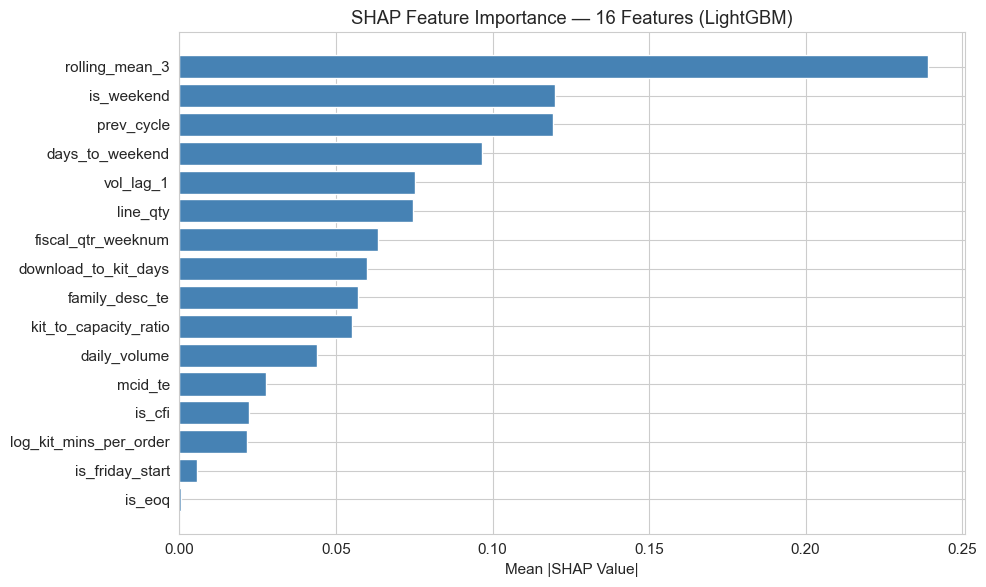

In [56]:
# ── SHAP Bar Plot ──
fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(range(len(shap_imp)), shap_imp['mean_abs_shap'].values, color='steelblue')
ax.set_yticks(range(len(shap_imp)))
ax.set_yticklabels(shap_imp['feature'].values)
ax.set_xlabel('Mean |SHAP Value|')
ax.set_title(f'SHAP Feature Importance — {len(FEATURES)} Features (LightGBM)')
ax.invert_yaxis()
plt.tight_layout()
plt.show()

## 6.3 SHAP Beeswarm Plot

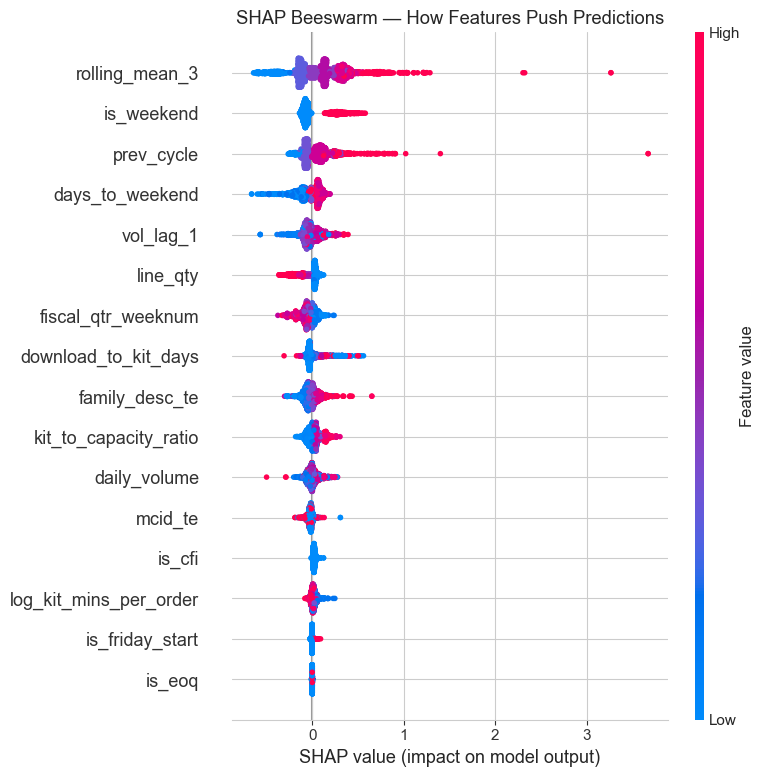

In [57]:
# ── SHAP Beeswarm Plot ──
# Shows HOW each feature affects predictions (red=high value, blue=low value)
plt.figure(figsize=(12, 8))
shap.summary_plot(shap_values, X_shap, feature_names=FEATURES, max_display=len(FEATURES), show=False)
plt.title('SHAP Beeswarm — How Features Push Predictions')
plt.tight_layout()
plt.show()

## 6.4 SHAP Comparison — All 3 Models

Computing SHAP for XGBoost and CatBoost...

SHAP Importance — All 3 Models:
───────────────────────────────────────────────────────────────────────────
  Feature                        LGB      XGB       CB      Avg
───────────────────────────────────────────────────────────────────────────
  rolling_mean_3              0.2390   0.2370   0.1775   0.2178
  is_weekend                  0.1200   0.1191   0.1415   0.1269
  prev_cycle                  0.1193   0.1154   0.1399   0.1249
  days_to_weekend             0.0967   0.1018   0.1213   0.1066
  vol_lag_1                   0.0752   0.0848   0.0659   0.0753
  line_qty                    0.0747   0.0961   0.0485   0.0731
  family_desc_te              0.0571   0.0573   0.0749   0.0631
  fiscal_qtr_weeknum          0.0633   0.0636   0.0603   0.0624
  download_to_kit_days        0.0600   0.0651   0.0566   0.0606
  kit_to_capacity_ratio       0.0552   0.0851   0.0358   0.0587
  daily_volume                0.0438   0.0554   0.0318   0.0437
  mc

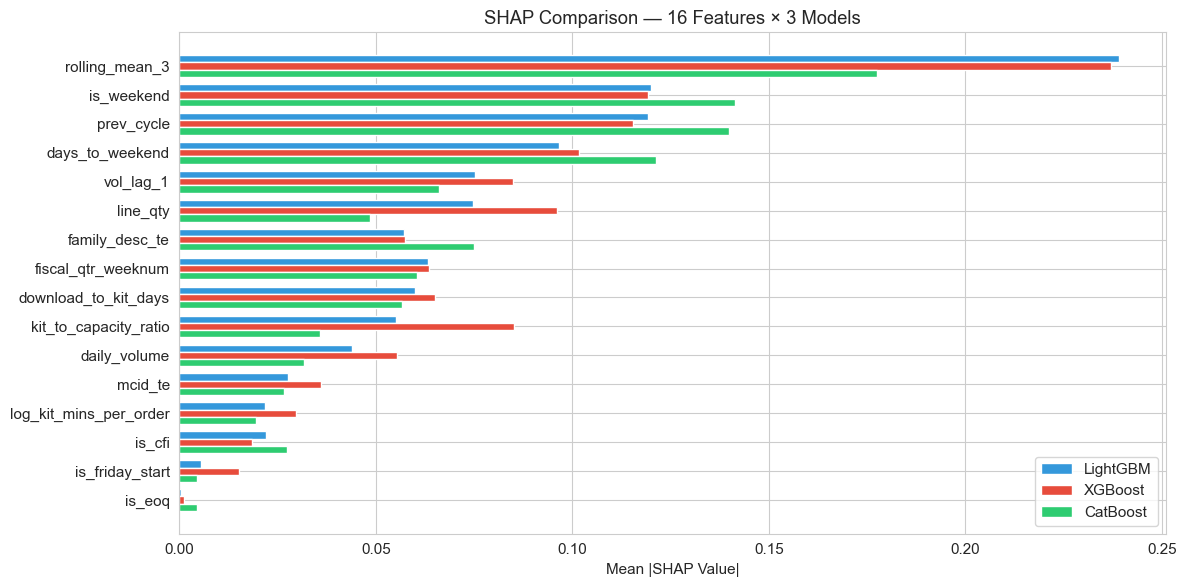

In [58]:
# ── SHAP for ALL 3 Models (comparison) ──
print("Computing SHAP for XGBoost and CatBoost...")

shap_xgb = shap.TreeExplainer(best_xgb).shap_values(X_shap)
shap_cb  = shap.TreeExplainer(best_cb).shap_values(X_shap)

shap_comparison = pd.DataFrame({
    'feature': FEATURES,
    'LightGBM': np.abs(shap_values).mean(axis=0),
    'XGBoost':  np.abs(shap_xgb).mean(axis=0),
    'CatBoost': np.abs(shap_cb).mean(axis=0),
})
shap_comparison['Average'] = shap_comparison[['LightGBM', 'XGBoost', 'CatBoost']].mean(axis=1)
shap_comparison = shap_comparison.sort_values('Average', ascending=False)

print(f"\nSHAP Importance — All 3 Models:")
print(f"{'─'*75}")
print(f"  {'Feature':<25s} {'LGB':>8s} {'XGB':>8s} {'CB':>8s} {'Avg':>8s}")
print(f"{'─'*75}")
for _, r in shap_comparison.iterrows():
    print(f"  {r['feature']:<25s} {r['LightGBM']:>8.4f} {r['XGBoost']:>8.4f} {r['CatBoost']:>8.4f} {r['Average']:>8.4f}")

# Side-by-side bar plot
fig, ax = plt.subplots(figsize=(12, 6))
x = np.arange(len(shap_comparison))
width = 0.25
ax.barh(x - width, shap_comparison['LightGBM'].values, width, label='LightGBM', color='#3498db')
ax.barh(x,         shap_comparison['XGBoost'].values,  width, label='XGBoost',  color='#e74c3c')
ax.barh(x + width, shap_comparison['CatBoost'].values, width, label='CatBoost', color='#2ecc71')
ax.set_yticks(x)
ax.set_yticklabels(shap_comparison['feature'].values)
ax.set_xlabel('Mean |SHAP Value|')
ax.set_title(f'SHAP Comparison — {len(FEATURES)} Features × 3 Models')
ax.legend()
ax.invert_yaxis()
plt.tight_layout()
plt.show()

---
# 7. Inference — Predict Kit End Dates

Apply the best model to 12,069 unseen orders.

## 7.1 Generate Predictions

In [ ]:
# ═══════════════════════════════════════════════════
# INFERENCE — PREDICT ON UNSEEN DATA
# ═══════════════════════════════════════════════════

# Prepare inference features (already computed during feature engineering)
X_inf = inference_df[FEATURES].fillna(0).astype(np.float32)

print(f"Inference data: {X_inf.shape}")
print(f"Features: {len(FEATURES)}")

# Generate predictions from all models
pred_lgb_inf = best.predict(X_inf)
pred_xgb_inf = best_xgb.predict(X_inf)
pred_cb_inf  = best_cb.predict(X_inf)

# Ensemble prediction
pred_ens_inf = w[0]*pred_lgb_inf + w[1]*pred_xgb_inf + w[2]*pred_cb_inf

# Use best approach (ensemble or single model)
if use_ensemble:
    final_pred_raw = pred_ens_inf
    final_model_used = "Ensemble"
elif best_model_name == 'LightGBM (Optuna)':
    final_pred_raw = pred_lgb_inf
    final_model_used = "LightGBM"
elif best_model_name == 'XGBoost (Optuna)':
    final_pred_raw = pred_xgb_inf
    final_model_used = "XGBoost"
else:
    final_pred_raw = pred_cb_inf
    final_model_used = "CatBoost"

# Post-process: round and clip
final_pred = np.clip(np.round(final_pred_raw), 0, None).astype(int)
inference_df['predicted_kit_cycle_days'] = final_pred

# ═══════════════════════════════════════════════════
# CALENDAR + CAPACITY AWARE KIT_END CALCULATION
# ═══════════════════════════════════════════════════
#
# Rule: A day is NON-WORKING only if:
#   Calendar says weekend/holiday AND capacity total_hours = 0
#
# If calendar says weekend BUT capacity has hours > 0 (overtime),
# the factory IS running → that day COUNTS as a working day.

# Step 1: Build capacity lookup → date: total_hours
capacity_hours = {}
if 'capacity_daily' in dir():
    cap_src = capacity_daily
elif 'date_features' in dir():
    cap_src = date_features
else:
    cap_src = None

if cap_src is not None:
    for _, row in cap_src.iterrows():
        d = pd.Timestamp(row['date']).date()
        capacity_hours[d] = row.get('total_hours', 0) or 0

# Step 2: Build non-working day set
non_working_days = set()
weekends_with_ot = 0

for _, row in calendar_df.iterrows():
    is_off = (row.get('is_weekend', 0) == 1) or (row.get('is_holiday', 0) == 1)
    if not is_off:
        continue

    d = pd.Timestamp(row['date']).date()
    hours = capacity_hours.get(d, 0)

    if hours > 0:
        weekends_with_ot += 1    # overtime → factory running → working day
    else:
        non_working_days.add(d)  # no capacity → truly non-working

print(f"Weekends/holidays in calendar: "
      f"{sum(1 for _, r in calendar_df.iterrows() if r.get('is_weekend',0)==1 or r.get('is_holiday',0)==1)}")
print(f"  With overtime (COUNTED as working): {weekends_with_ot}")
print(f"  Truly non-working (0 capacity):     {len(non_working_days)}")

# Step 3: Compute kit_end by stepping through working days only
def compute_kit_end(kit_start, cycle_days, non_working_set):
    """
    Step forward from kit_start, counting only working days.
    
    0 cycle days → kit_end = kit_start (same-day completion)
    N cycle days → skip non-working days, count N working days
    
    Example: kit_start=Fri, cycle=2, Sat has OT, Sun has 0h
      Fri → Sat(OT→working, count 1) → Sun(0h→skip) → Mon(count 2) = Monday
    """
    if cycle_days == 0:
        return kit_start
    
    current = kit_start
    counted = 0
    
    while counted < cycle_days:
        current += pd.Timedelta(days=1)
        if current.date() not in non_working_set:
            counted += 1
        if (current - kit_start).days > cycle_days + 30:
            break  # safety
    
    return current

print("\nComputing calendar+capacity-aware kit_end...")
inference_df['predicted_kit_end'] = [
    compute_kit_end(row['kit_start'], row['predicted_kit_cycle_days'], non_working_days)
    for _, row in inference_df.iterrows()
]

# Step 4: Compare with naive to show the impact
naive_end = inference_df['kit_start'] + pd.to_timedelta(final_pred, unit='D')
shift = (inference_df['predicted_kit_end'] - naive_end).dt.days
shifted_count = (shift != 0).sum()

print(f"\n Kit_end computed (calendar + capacity aware)")
print(f"   Orders shifted vs naive: {shifted_count:,} / {len(inference_df):,} ({shifted_count/len(inference_df)*100:.1f}%)")
if shifted_count > 0:
    print(f"   Avg shift: {shift[shift != 0].mean():.1f} days")
    print(f"\n   {'kit_start':>12s}  {'DOW':>5s}  {'cycle':>5s}  {'naive':>12s}  {'smart':>12s}  {'shift':>5s}")
    print(f"   {'─'*60}")
    for _, row in inference_df[shift != 0].head(10).iterrows():
        n = (row['kit_start'] + pd.Timedelta(days=row['predicted_kit_cycle_days'])).strftime('%Y-%m-%d')
        s = row['predicted_kit_end'].strftime('%Y-%m-%d')
        d = (row['predicted_kit_end'] - (row['kit_start'] + pd.Timedelta(days=row['predicted_kit_cycle_days']))).days
        print(f"   {row['kit_start'].strftime('%Y-%m-%d'):>12s}  {row['kit_start'].strftime('%a'):>5s}  "
              f"{row['predicted_kit_cycle_days']:>5d}  {n:>12s}  {s:>12s}  {d:>+5d}")

print(f"\nUsing: {final_model_used}")
print(f"Predictions: {len(final_pred)}")
print(f"\nPrediction distribution:")
for d in range(8):
    n = (final_pred == d).sum()
    if n > 0:
        print(f"  {d} days: {n:>5,} ({n/len(final_pred)*100:.1f}%)")

print(f"\nSample predictions (calendar+capacity aware):")
sample_cols = ['sales_order_id', 'family_desc', 'kit_start', 'predicted_kit_cycle_days', 'predicted_kit_end']
print(inference_df[sample_cols].head(15).to_string(index=False))
# ```

# Drop this in as a direct replacement for your inference cell. The logic is:
# ```
# Weekend/holiday + capacity hours > 0  →  factory has overtime  →  WORKING DAY
# Weekend/holiday + capacity hours = 0  →  factory closed        →  SKIP
# Regular weekday                       →  always WORKING DAY

Inference data: (12069, 16)
Features: 16
Weekends/holidays in calendar: 116
  With overtime (COUNTED as working): 68
  Truly non-working (0 capacity):     48

Computing calendar+capacity-aware kit_end...

✅ Kit_end computed (calendar + capacity aware)
   Orders shifted vs naive: 3,304 / 12,069 (27.4%)
   Avg shift: 1.0 days

      kit_start    DOW  cycle         naive         smart  shift
   ────────────────────────────────────────────────────────────
     2026-02-12    Thu      3    2026-02-15    2026-02-16     +1
     2026-02-13    Fri      2    2026-02-15    2026-02-16     +1
     2026-02-13    Fri      2    2026-02-15    2026-02-16     +1
     2026-02-20    Fri      2    2026-02-22    2026-02-23     +1
     2026-02-13    Fri      2    2026-02-15    2026-02-16     +1
     2026-02-13    Fri      3    2026-02-16    2026-02-17     +1
     2026-02-26    Thu      3    2026-03-01    2026-03-02     +1
     2026-02-21    Sat      3    2026-02-24    2026-02-25     +1
     2026-03-06    Fri  

## 7.2 Save Outputs

In [60]:
# ═══════════════════════════════════════════════════
# SAVE ALL OUTPUTS
# ═══════════════════════════════════════════════════

OUTPUT_DIR = "data/output"
os.makedirs(OUTPUT_DIR, exist_ok=True)

# 1. NUMPY ARRAY — predictions in same order as inference.csv (REQUIRED for submission)
np.save(f"{OUTPUT_DIR}/Naveena_DS_Case_Predictions_2026.npy", final_pred)
print(f" Saved predictions numpy array: {final_pred.shape}")
print(f"   File: {OUTPUT_DIR}/Naveena_DS_Case_Predictions_2026.npy")

# Verify: load and check
loaded = np.load(f"{OUTPUT_DIR}/Naveena_DS_Case_Predictions_2026.npy")
print(f"   Verification: shape={loaded.shape}, dtype={loaded.dtype}, "
      f"mean={loaded.mean():.2f}, min={loaded.min()}, max={loaded.max()}")

# 2. Kit end dates as numpy array (bonus)
kit_end_dates = inference_df['predicted_kit_end'].dt.strftime('%Y-%m-%d').values
np.save(f"{OUTPUT_DIR}/Naveena_DS_Case_Kit_End_Dates_2026.npy", kit_end_dates)
print(f"\n Saved kit_end dates: {kit_end_dates.shape}")

# 3. Full inference predictions as CSV (for review)
inf_output = inference_df[['sales_order_id', 'family_desc', 'kit_start', 'est_ship_date',
                            'predicted_kit_cycle_days', 'predicted_kit_end']].copy()
inf_output.to_csv(f"{OUTPUT_DIR}/Naveena_DS_Case_Inference_Results_2026.csv", index=False)
print(f" Saved inference results CSV: {inf_output.shape}")

# 4. Performance metrics
results_df.to_csv(f"{OUTPUT_DIR}/Naveena_DS_Case_Metrics_2026.csv", index=False)
print(f" Saved performance metrics")

# 5. SHAP importance
shap_comparison.to_csv(f"{OUTPUT_DIR}/Naveena_DS_Case_SHAP_2026.csv", index=False)
print(f" Saved SHAP importance")

print(f"\n{'='*60}")
print(f"  SUBMISSION SUMMARY")
print(f"{'='*60}")
print(f"  Model used:        {final_model_used}")
print(f"  Best MAE:          {results_df.iloc[0]['MAE']:.4f}")
print(f"  Features:          {len(FEATURES)}")
print(f"  Inference rows:    {len(final_pred)}")
print(f"  Predictions file:  Naveena_DS_Case_Predictions_2026.npy")
print(f"{'='*60}")

 Saved predictions numpy array: (12069,)
   File: data/output/Naveena_DS_Case_Predictions_2026.npy
   Verification: shape=(12069,), dtype=int64, mean=1.75, min=0, max=5

 Saved kit_end dates: (12069,)
 Saved inference results CSV: (12069, 6)
 Saved performance metrics
 Saved SHAP importance

  SUBMISSION SUMMARY
  Model used:        XGBoost
  Best MAE:          0.8486
  Features:          16
  Inference rows:    12069
  Predictions file:  Naveena_DS_Case_Predictions_2026.npy


---
# Summary & Business Recommendations


## Key Features Driving Predictions

1. **Rolling family cycle time** (`prev_cycle`, `rolling_mean_7`) — Recent history of the same product family is the strongest predictor
2. **Day-of-week** (`is_friday_start`, `days_to_weekend`, `is_weekend`) — Weekend/holiday gaps directly extend cycle time
3. **Product identity** (`family_desc_te`, `mcid_te`) — Different products and warehouses have inherently different cycle times
4. **Factory load** (`daily_volume`, `vol_lag_1`) — Higher order volume → longer cycles

## Business Recommendations

1. **Schedule optimization**: Avoid starting kitting on Fridays when possible — weekend gaps add 1–2 days to cycle time
2. **Capacity planning**: Monitor daily_volume as a leading indicator — when volume spikes, proactively add capacity
3. **Product-specific SLAs**: Set different delivery expectations per product family based on their historical cycle patterns
4. **End-of-quarter preparation**: Fiscal quarter-end weeks show elevated cycle times — pre-position materials early